# Predicción del cáncer de mama usando PCA y Agrupamiento con K-Means (Semana 3)

**Maestría en Inteligencia Artificial Aplicada — UIDE**
**Asignatura:** Aprendizaje Automático Estadístico — MIA-B
**Docente:** PhD. Iván García Santillán
**Semana 3 — Componente práctico (Práctica Grupal — Grupo 2)**

**Integrantes (Grupo 2):**
- Gualli Ramírez, Jonathan Fabricio
- Quizamánchuro Fuel, Jorge Armando
- Salazar Gamboa, Raúl Marcelo

---

## Resumen del trabajo

Este notebook desarrolla un flujo completo de **clasificación binaria supervisada** sobre el dataset
**Breast Cancer Wisconsin Diagnostic (WBCD)** del repositorio UCI, con el objetivo de distinguir
tumores **malignos** de **benignos** a partir de las 30 características morfológicas calculadas sobre
imágenes digitalizadas de aspirados con aguja fina (FNA).

Se realiza la predicción del cancer de mama utilizando el algoritmo de reducciones de dimensiones PCA y los algoritmos de clasificación, así como realizar tareas de agrupamiento (clustering) y la evaluación de los algoritmos usando las métricas y gráficas respectivas.


> **Clase positiva = `Maligno = 1`** **Clase negativa = `Benigno = 0`** Priorizamos el **Recall**: en un contexto del Falso Negativo (predecir que no es Cancer cuando si lo es) es el error mas grave.

## 1. Configuración del entorno y carga de librerías

Se fija una **semilla global (`SEED = 42`)** en todas las funciones que la admitan para garantizar
la reproducibilidad de los resultados (divisiones, búsquedas de hiperparámetros, etc.).

In [ ]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import tensorflow as tf

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

# Reproducibilidad
SEED = 42
np.random.seed(SEED)

# Estilo de gráficos
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

# Rutas relativas desde la raíz del proyecto
NB_DIR = Path.cwd()
PROJ_DIR = NB_DIR.parent
MODELS_DIR = PROJ_DIR / "models"
OUT_DIR = PROJ_DIR / "outputs"
MODELS_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)

print("scikit-learn, pandas y seaborn cargados correctamente.")
print(f"Modelos se guardarán en: {MODELS_DIR}")

scikit-learn, pandas y seaborn cargados correctamente.
Modelos se guardarán en: /models


---
# Fase I — Preprocesamiento

Antes de modelar necesitamos un conjunto de datos limpio, con la etiqueta
correctamente codificada para la interpretación clínica, sin columnas que introduzcan fuga de
información o ruido, y con las escalas adecuadas para algoritmos sensibles a la distancia (KNN).

## 2. Carga del dataset y recodificación de la etiqueta

El WBCD está disponible en UCI (`http://archive.ics.uci.edu/dataset/17/`) y también empaquetado en
`sklearn.datasets.load_breast_cancer()`. Usamos la versión de scikit-learn por ser reproducible y no
depender de la red; es **idéntica** en variables y muestras al fichero de UCI.

> **Criterio de codificación.** scikit-learn usa `0 = maligno`, `1 = benigno` (al revés
> de lo que nos interesa clínicamente). Para que **la clase positiva (1) sea el tumor maligno**
> invertimos la etiqueta con `y = 1 - y`. Así `1 = maligno (positivo)` y `0 = benigno (negativo)`,
> que es lo solicitado (M=1, B=0).

In [ ]:
data = load_breast_cancer(as_frame=True)
df = data.frame.copy()

# sklearn: target 0=maligno, 1=benigno  -> invertimos para que 1=maligno (clase positiva)
df["target"] = 1 - df["target"]

# Mapeo legible
LABELS = {1: "Maligno (M)", 0: "Benigno (B)"}

print(f"Dimensiones del dataset: {df.shape[0]} muestras x {df.shape[1]-1} características + objetivo")
print(f"\nCodificación objetivo -> 1 = Maligno (positivo), 0 = Benigno (negativo)")
print(df["target"].map(LABELS).value_counts())
df.head()

Dimensiones del dataset: 569 muestras x 30 características + objetivo

Codificación objetivo -> 1 = Maligno (positivo), 0 = Benigno (negativo)
target
Benigno (B)    357
Maligno (M)    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


**La columna ID:** el fichero original de UCI incluye una columna identificadora del paciente
(`ID number`) que **no aporta poder predictivo** y debe descartarse para evitar que el modelo aprenda
ruido. La versión de scikit-learn ya viene **sin esa columna**, por lo que no hay nada que eliminar;
dejamos constancia explícita de la verificación.

In [ ]:
id_like = [c for c in df.columns if c.lower() in ("id", "id number", "id_number")]
if id_like:
    df = df.drop(columns=id_like)
    print(f"Columna(s) ID eliminada(s): {id_like}")
else:
    print("No existe columna ID en esta versión (sklearn ya la excluye). Verificación OK.")

print(f"Columnas predictoras: {df.shape[1]-1}")

No existe columna ID en esta versión (sklearn ya la excluye). Verificación OK.
Columnas predictoras: 30


## 3. Verificación de valores perdidos

Reportamos los valores nulos por columna. El WBCD es un dataset curado y **no contiene valores
perdidos**.

In [ ]:
missing = df.isnull().sum()
total_missing = int(missing.sum())
print(f"Total de valores perdidos en el dataset: {total_missing}")
if total_missing == 0:
    print("No se requiere imputación.")
else:
    print(missing[missing > 0])

Total de valores perdidos en el dataset: 0
No se requiere imputación.


## 4. Detección y tratamiento de valores atípicos

**Decisión crítica (y deliberada):** en datos clínicos los valores extremos **no son errores de
medición**, sino justamente la señal que distingue un tumor agresivo. Eliminarlos puede borrar la
información más útil para detectar malignidad. Por eso **detectamos y cuantificamos** los atípicos,
pero la decisión de eliminarlos o conservarlos la tomaremos **empíricamente** en la Fase III
(experimento "eliminar vs conservar"), no por defecto.

In [ ]:
feature_cols = [c for c in df.columns if c != "target"]

def iqr_outlier_mask(frame, cols):
    mask = pd.Series(False, index=frame.index)
    counts = {}
    for col in cols:
        q1, q3 = frame[col].quantile(0.25), frame[col].quantile(0.75)
        iqr = q3 - q1
        low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        col_out = (frame[col] < low) | (frame[col] > high)
        counts[col] = int(col_out.sum())
        mask |= col_out
    return mask, counts

outlier_mask, outlier_counts = iqr_outlier_mask(df, feature_cols)
n_rows_outlier = int(outlier_mask.sum())

print(f"Filas con al menos un atípico IQR: {n_rows_outlier} de {len(df)} "
      f"({100*n_rows_outlier/len(df):.1f}%)")
print("\nTop-8 variables con más atípicos:")
print(pd.Series(outlier_counts).sort_values(ascending=False).head(8))

Filas con al menos un atípico IQR: 171 de 569 (30.1%)

Top-8 variables con más atípicos:
area error                 65
radius error               38
perimeter error            38
worst area                 35
smoothness error           30
fractal dimension error    28
compactness error          28
symmetry error             27
dtype: int64


---
# Fase II — Análisis Exploratorio de Datos (EDA)

Entender la estructura de los datos antes de modelar nos permite detectar el desbalance de
clases, identificar las variables más informativas y justificar la selección de
características con criterio estadístico.

## 5. Distribución de la variable objetivo (balance de clases)

El dataset tiene **357 benignos y 212 malignos** (63% / 37%). Es un desbalance **moderado**, no
severo, por lo que no requiere remuestreo.

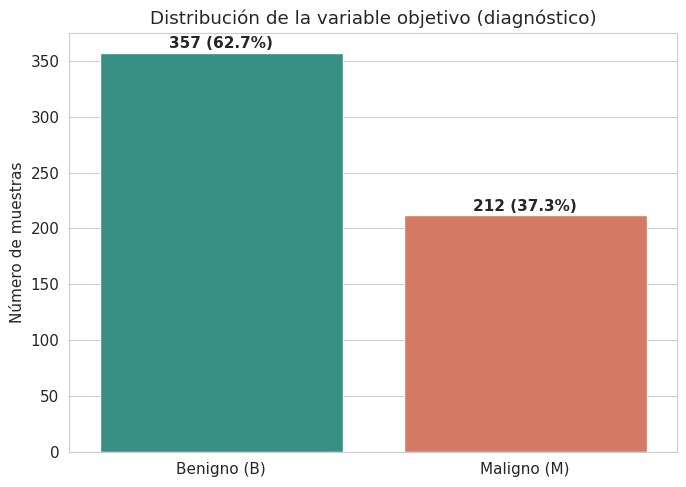

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
counts = df["target"].map(LABELS).value_counts()
sns.barplot(x=counts.index, y=counts.values, palette=["#2a9d8f", "#e76f51"], ax=ax)
for i, v in enumerate(counts.values):
    ax.text(i, v + 4, f"{v} ({100*v/len(df):.1f}%)", ha="center", fontweight="bold")
ax.set_title("Distribución de la variable objetivo (diagnóstico)")
ax.set_ylabel("Número de muestras"); ax.set_xlabel("")
plt.tight_layout(); plt.savefig(OUT_DIR / "01_distribucion_clases.png", dpi=120); plt.show()

## 6. Estadística descriptiva de las variables más relevantes

Mostramos un resumen de las variables de tipo *mean* (las 10 magnitudes promedio), que suelen ser las
más interpretables clínicamente.

In [ ]:
mean_cols = [c for c in feature_cols if c.startswith("mean")]
df[mean_cols].describe().T[["mean", "std", "min", "50%", "max"]].round(3)

,mean,std,min,50%,max
mean radius,14.127,3.524,6.981,13.370,28.110
mean texture,19.290,4.301,9.710,18.840,39.280
mean perimeter,91.969,24.299,43.790,86.240,188.500
mean area,654.889,351.914,143.500,551.100,2501.000
mean smoothness,0.096,0.014,0.053,0.096,0.163
mean compactness,0.104,0.053,0.019,0.093,0.345
mean concavity,0.089,0.080,0.000,0.062,0.427
mean concave points,0.049,0.039,0.000,0.034,0.201
mean symmetry,0.181,0.027,0.106,0.179,0.304
mean fractal dimension,0.063,0.007,0.050,0.062,0.097


## 7. Correlación de cada variable con el objetivo y selección de características

Calculamos la correlación de Pearson de cada predictora con `target` y seleccionamos
las que superan un **umbral de |correlación| > 0.4** (correlación moderada-alta). Esta es nuestra
estrategia de **selección de características** para la versión mejorada de los modelos.

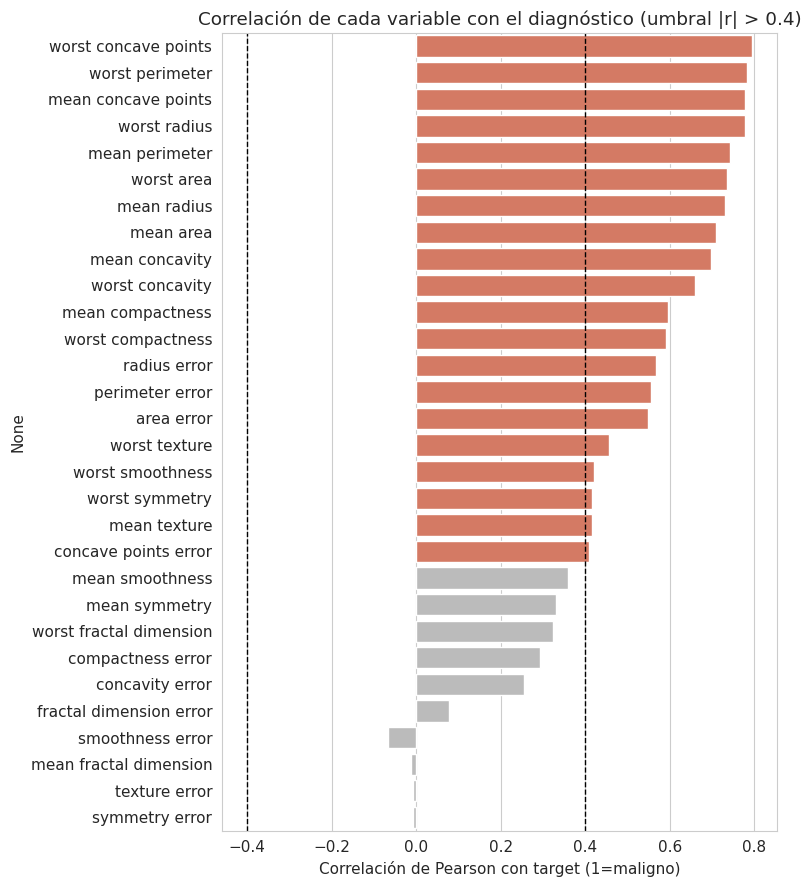

Variables seleccionadas (|r| > 0.4): 20 de 30
  worst concave points         r = +0.794
  worst perimeter              r = +0.783
  mean concave points          r = +0.777
  worst radius                 r = +0.776
  mean perimeter               r = +0.743
  worst area                   r = +0.734
  mean radius                  r = +0.730
  mean area                    r = +0.709
  mean concavity               r = +0.696
  worst concavity              r = +0.660
  mean compactness             r = +0.597
  worst compactness            r = +0.591
  radius error                 r = +0.567
  perimeter error              r = +0.556
  area error                   r = +0.548
  worst texture                r = +0.457
  worst smoothness             r = +0.421
  worst symmetry               r = +0.416
  mean texture                 r = +0.415
  concave points error         r = +0.408


In [ ]:
corr_target = df.corr(numeric_only=True)["target"].drop("target").sort_values(key=np.abs, ascending=False)

THRESHOLD = 0.4
selected_features = corr_target[corr_target.abs() > THRESHOLD].index.tolist()

fig, ax = plt.subplots(figsize=(8, 9))
colors = ["#e76f51" if abs(v) > THRESHOLD else "#bbbbbb" for v in corr_target.values]
sns.barplot(x=corr_target.values, y=corr_target.index, palette=colors, ax=ax)
ax.axvline(THRESHOLD, color="k", ls="--", lw=1); ax.axvline(-THRESHOLD, color="k", ls="--", lw=1)
ax.set_title(f"Correlación de cada variable con el diagnóstico (umbral |r| > {THRESHOLD})")
ax.set_xlabel("Correlación de Pearson con target (1=maligno)")
plt.tight_layout(); plt.savefig(OUT_DIR / "02_correlacion_target.png", dpi=120); plt.show()

print(f"Variables seleccionadas (|r| > {THRESHOLD}): {len(selected_features)} de {len(feature_cols)}")
for f in selected_features:
    print(f"  {f:<28} r = {corr_target[f]:+.3f}")

## 8. Histogramas de las variables más predictivas

Comparamos la distribución de las 4 variables con mayor correlación, separadas por clase. Se observa
una **clara separación** entre malignos y benignos: los tumores malignos tienden a valores más altos
de tamaño/concavidad, lo que anticipa que el problema es **bien separable** linealmente; es decir, con poco solapamiento entre clases.

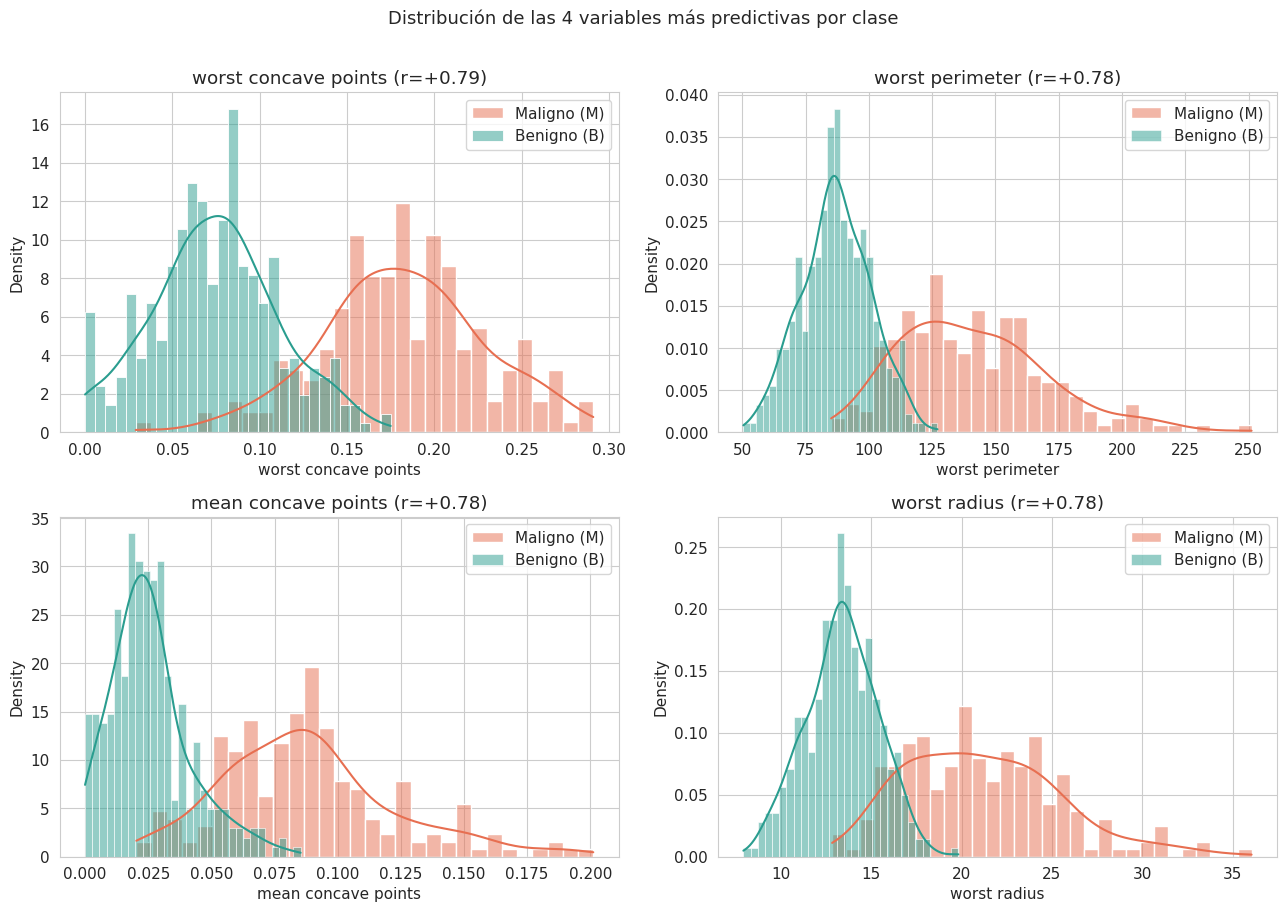

In [ ]:
top4 = selected_features[:4]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.ravel(), top4):
    for cls, color in [(1, "#e76f51"), (0, "#2a9d8f")]:
        sns.histplot(df[df.target == cls][col], ax=ax, color=color, label=LABELS[cls],
                     kde=True, stat="density", alpha=0.5, bins=30)
    ax.set_title(f"{col} (r={corr_target[col]:+.2f})"); ax.legend()
fig.suptitle("Distribución de las 4 variables más predictivas por clase", y=1.01, fontsize=13)
plt.tight_layout(); plt.savefig(OUT_DIR / "03_histogramas_top.png", dpi=120); plt.show()

## 9. Boxplots para detección visual de atípicos

Los boxplots confirman el análisis de la Fase I: existen valores extremos, **concentrados en la
clase maligna**. Esto sustenta la decisión de **no eliminarlos a ciegas**.

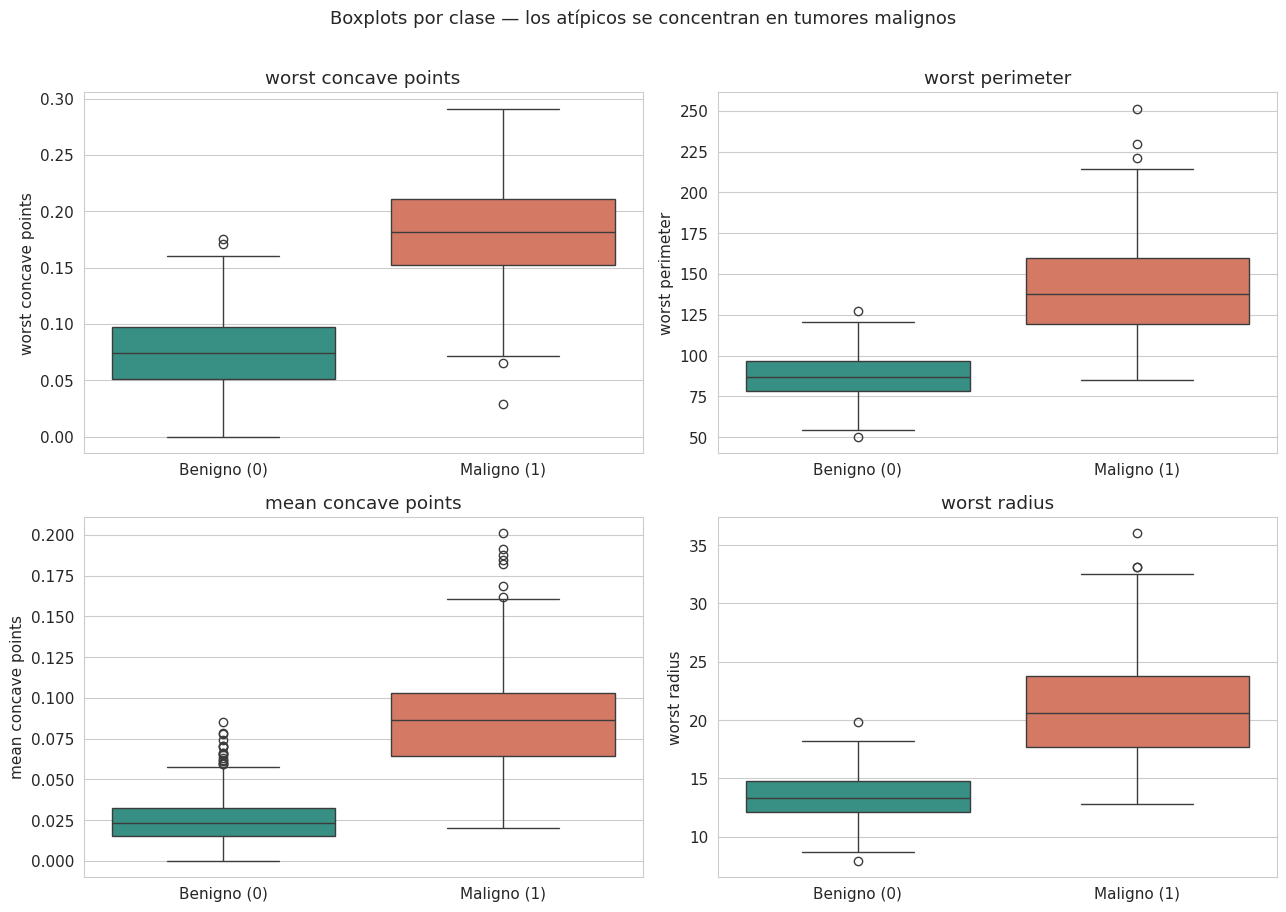

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.ravel(), top4):
    sns.boxplot(data=df, x="target", y=col, palette=["#2a9d8f", "#e76f51"], ax=ax)
    ax.set_xticklabels(["Benigno (0)", "Maligno (1)"])
    ax.set_title(col); ax.set_xlabel("")
fig.suptitle("Boxplots por clase — los atípicos se concentran en tumores malignos", y=1.01, fontsize=13)
plt.tight_layout(); plt.savefig(OUT_DIR / "04_boxplots.png", dpi=120); plt.show()

## 10. Matriz de correlación entre predictoras

Vamos a detectar la **multicolinealidad**. En el WBCD muchas variables son geométricamente
redundantes (p. ej. `mean radius`, `mean perimeter` y `mean area` miden esencialmente el tamaño y
correlacionan > 0.9). Esto justifica la selección de características y advierte que los coeficientes
de la Regresión Logística deben interpretarse con cautela.

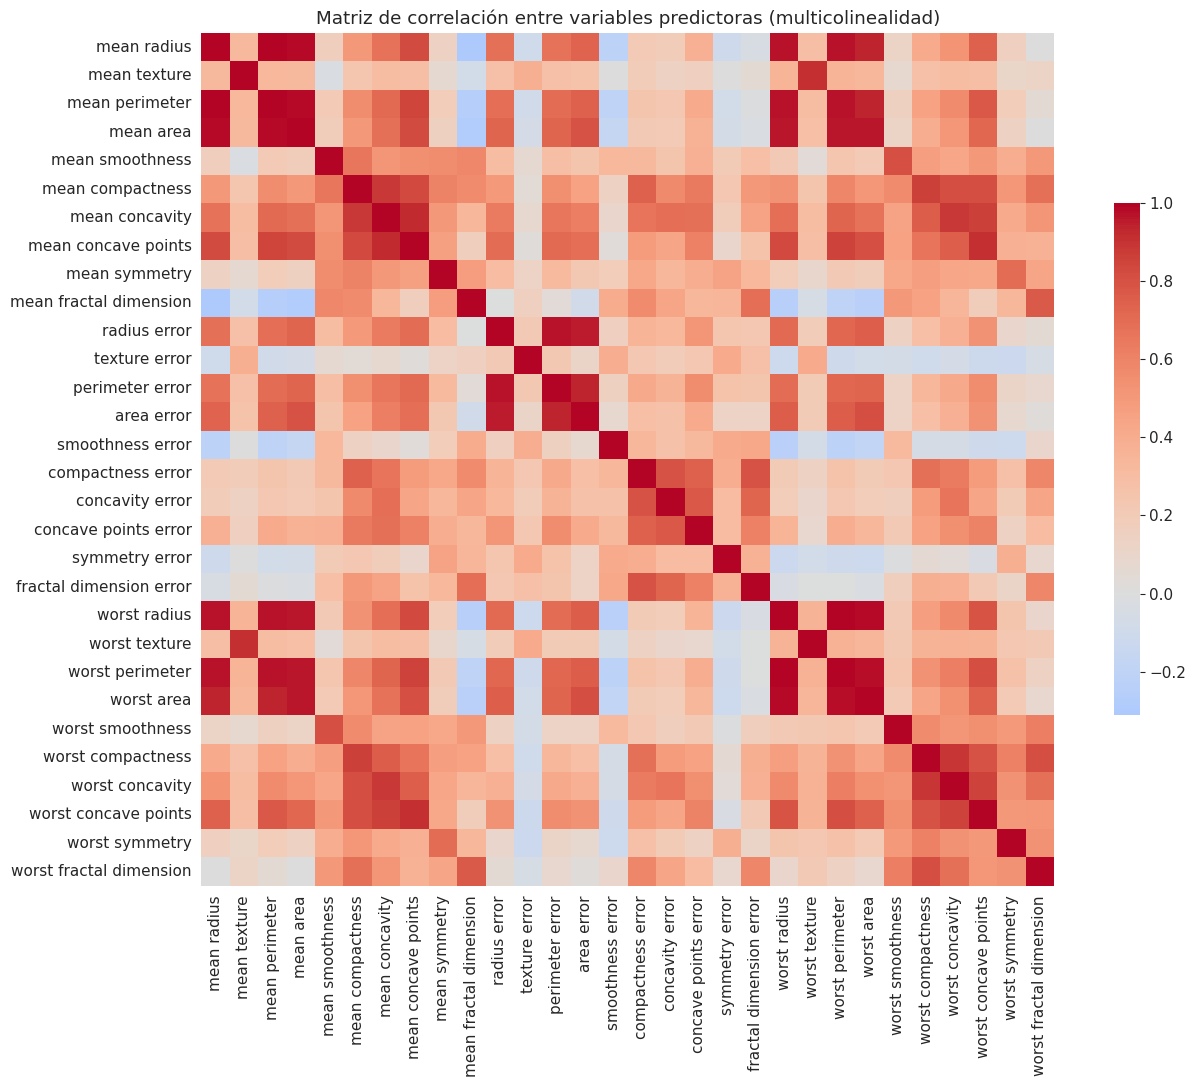

In [ ]:
fig, ax = plt.subplots(figsize=(14, 11))
corr_matrix = df[feature_cols].corr()
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, square=True,
            cbar_kws={"shrink": 0.6}, ax=ax)
ax.set_title("Matriz de correlación entre variables predictoras (multicolinealidad)")
plt.tight_layout(); plt.savefig(OUT_DIR / "05_heatmap_correlacion.png", dpi=120); plt.show()

### Conclusiones del análisis:

- **Balance:** desbalance moderado (63% benigno / 37% maligno).
- **Variables más predictivas:** las relacionadas con **tamaño** (`worst perimeter`, `worst radius`,
  `worst area`) y **forma/concavidad** (`worst concave points`, `mean concave points`) son las de
  mayor correlación con malignidad (|r| > 0.7).
- **Multicolinealidad alta** entre variables de tamaño → justifica la selección por correlación y la
  cautela al interpretar coeficientes.
- **Separabilidad:** los histogramas muestran clases bien separadas.

---
# Fase III — Modelado y Evaluación

Entrenamos cuatro clasificadores clásicos, cada uno en dos versiones
(*baseline* y *mejorada*). Mantenemos un **conjunto de prueba intacto (20%)** con división
**estratificada** para que el balance de clases se conserve, y usamos `random_state=42` en todo.

## 11. División train/test y preparación de escaladores

- **División:** 80% entrenamiento / 20% prueba, **estratificada** por la clase.
- **Escalado:** ajustamos los escaladores **solo con los datos de entrenamiento** (para evitar fuga de
  información) y los aplicamos al test. Preparamos las dos versiones (`StandardScaler` y
  `MinMaxScaler`) para el experimento comparativo.

In [ ]:
X = df[feature_cols].copy()
y = df["target"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)
print(f"Train: {X_train.shape[0]} muestras | Test: {X_test.shape[0]} muestras")
print(f"Balance train: {dict(y_train.map(LABELS).value_counts())}")
print(f"Balance test : {dict(y_test.map(LABELS).value_counts())}")

# Escaladores ajustados SOLO con train
std_scaler = StandardScaler().fit(X_train)
mm_scaler  = MinMaxScaler().fit(X_train)

X_train_std, X_test_std = std_scaler.transform(X_train), std_scaler.transform(X_test)
X_train_mm,  X_test_mm  = mm_scaler.transform(X_train),  mm_scaler.transform(X_test)

Train: 455 muestras | Test: 114 muestras
Balance train: {'Benigno (B)': np.int64(285), 'Maligno (M)': np.int64(170)}
Balance test : {'Benigno (B)': np.int64(72), 'Maligno (M)': np.int64(42)}


In [ ]:
from sklearn.model_selection import StratifiedKFold

# Índices de las variables seleccionadas (para versión mejorada)
sel_idx = [feature_cols.index(f) for f in selected_features]
# Validación cruzada estratificada para GridSearch
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

X_train_sel_std = X_train_std[:, sel_idx]
X_test_sel_std = X_test_std[:, sel_idx]

## 12. Análisis con StandardScaler y MinMaxScaler

Antes de fijar el preprocesamiento comparamos ambos normalizadores.

In [ ]:
scaler_results = []
for name, Xtr, Xte in [("StandardScaler", X_train_std, X_test_std),
                       ("MinMaxScaler",  X_train_mm,  X_test_mm)]:
    clf = LogisticRegression(max_iter=5000, random_state=SEED).fit(Xtr, y_train)
    pred = clf.predict(Xte)
    scaler_results.append({
        "Escalador": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Recall (maligno)": recall_score(y_test, pred),
        "F1 (maligno)": f1_score(y_test, pred),
    })
scaler_df = pd.DataFrame(scaler_results).round(4)
print(scaler_df.to_string(index=False))

     Escalador  Accuracy  Recall (maligno)  F1 (maligno)
StandardScaler    0.9649            0.9286        0.9512
  MinMaxScaler    0.9737            0.9286        0.9630


**Considerando el resultado anterior, el recall es idéntico con ambos escaladores. Se adopta StandardScaler como normalizador base.

## 13. Análisis: eliminar o conservar los atípicos

Comparamos el desempeño entrenando (a) con todos los datos y (b) eliminando del **entrenamiento** las
filas con atípicos. **Nunca** tocamos el conjunto de prueba. Dejamos que los datos decidan y
analizamos el resultado con criterio clínico, sin presuponer la conclusión.

In [ ]:
# Máscara de atípicos calculada SOLO sobre el train
train_outlier_mask, _ = iqr_outlier_mask(X_train.assign(target=y_train), feature_cols)
keep_idx = ~train_outlier_mask.values

exp_b = []
for label, Xtr, ytr in [("Conservar atípicos", X_train_std, y_train),
                         ("Eliminar atípicos",  X_train_std[keep_idx], y_train[keep_idx])]:
    clf = LogisticRegression(max_iter=5000, random_state=SEED).fit(Xtr, ytr)
    pred = clf.predict(X_test_std)
    exp_b.append({
        "Estrategia": label,
        "n_train": len(ytr),
        "Accuracy": accuracy_score(y_test, pred),
        "Recall (maligno)": recall_score(y_test, pred),
        "F1 (maligno)": f1_score(y_test, pred),
    })
exp_b_df = pd.DataFrame(exp_b).round(4)
print(exp_b_df.to_string(index=False))

        Estrategia  n_train  Accuracy  Recall (maligno)  F1 (maligno)
Conservar atípicos      455    0.9649            0.9286        0.9512
 Eliminar atípicos      320    0.9737            0.9286        0.9630


Considerando el resultado anterior, el recall (prioridad clínica) es IDÉNTICO en ambas estrategias; eliminar solo mejora de forma marginal accuracy/F1 en ESTA partición, a costa de descartar ~30% del entrenamiento y la señal de los tumores más agresivos. Por eso conservamos todos los datos: **no eliminamos ninguna fila.**

## 14. Funciones de evaluación reutilizables

Definimos utilidades para (a) calcular todas las métricas, (b) dibujar la matriz de confusión anotada con TN/FP/FN/TP y (c) dibujar la curva ROC con su AUC. Así el código de cada modelo queda limpio y consistente.

In [ ]:
results = []   # se irá llenando con cada modelo/versión
all_confusion_data = [] # almacenamiento de los datos de la matriz de confusion
all_roc_data = []       # almacena los datos del roc de cada modelo

def evaluate(model, Xte, yte, name, version, save_key=None):
    # Calcula todas las metricas, las registra en results y devuelve (dict, pred, proba)
    if isinstance(model, tf.keras.Model):
        proba_raw = model.predict(Xte, verbose=0)
        proba = proba_raw.ravel()
        # Convvertimos probabilidades a predicciones binarias (0 o 1) usando un umbral
        pred = (proba > 0.5).astype(int)
    else: # Scikit-learn models
        pred = model.predict(Xte)
        proba = model.predict_proba(Xte)[:, 1]

    row = {
        "Modelo": name, "Versión": version,
        "Accuracy": accuracy_score(yte, pred),
        "Precision": precision_score(yte, pred),
        "Recall": recall_score(yte, pred),
        "F1": f1_score(yte, pred),
        "AUC": roc_auc_score(yte, proba),
    }
    results.append(row)
    return row, pred, proba

def plot_confusion(yte, pred, title, save_key=None, show_plot=True):
    cm = confusion_matrix(yte, pred)
    tn, fp, fn, tp = cm.ravel()
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    labels = np.array([[f"TN\n{tn}", f"FP\n{fp}"], [f"FN\n{fn}", f"TP\n{tp}"]])
    sns.heatmap(cm, annot=labels, fmt="", cmap="Blues", cbar=False,
                xticklabels=["Benigno (0)", "Maligno (1)"],
                yticklabels=["Benigno (0)", "Maligno (1)"], ax=ax)
    ax.set_xlabel("Predicción"); ax.set_ylabel("Real"); ax.set_title(title)
    plt.tight_layout()
    if save_key:
        plt.savefig(OUT_DIR / save_key, dpi=120)
    if show_plot:
        plt.show()
    else:
        plt.close(fig)
    return tn, fp, fn, tp

def plot_roc(curves, title, save_key=None, show_plot=True):

    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    for label, yte, proba in curves:
        fpr, tpr, _ = roc_curve(yte, proba)
        auc = roc_auc_score(yte, proba)
        ax.plot(fpr, tpr, lw=2, label=f"{label} (AUC={auc:.3f})")
    ax.plot([0, 1], [0, 1], "k--", lw=1, label="Azar")
    ax.set_xlabel("Tasa de Falsos Positivos"); ax.set_ylabel("Tasa de Verdaderos Positivos (Recall)")
    ax.set_title(title); ax.legend(loc="lower right")
    plt.tight_layout()
    if save_key:
        plt.savefig(OUT_DIR / save_key, dpi=120)
    if show_plot:
        plt.show()
    else:
        plt.close(fig)


In [ ]:
import os


best_models = {}
model_sizes = {}

all_confusion_data = []
all_roc_data = []
results = []

def get_model_size(model_path):
    """Returns the size of a model file in MB."""
    if Path(model_path).exists():
        return Path(model_path).stat().st_size / (1024 * 1024)
    return 0.0

def train_and_evaluate_classifier(classifier, params, X_train, y_train, X_test, y_test, name, version, save_key):
    print(f"--- Entrenando {name} ({version}) ---")

    # GridSearchCV for hyperparameter tuning
    grid_search = GridSearchCV(classifier, params, cv=cv, scoring='recall', n_jobs=-1, verbose=0)
    grid_search.fit(X_train, y_train)

    best_classifier = grid_search.best_estimator_
    best_params = grid_search.best_params_

    print(f"Mejores parámetros: {best_params}")

    # Evaluate the best model
    metrics, pred, proba = evaluate(best_classifier, X_test, y_test, name, version, save_key)
    print("Métricas en Test:")
    # Display the metrics dictionary
    display(pd.DataFrame([metrics]))

    # Prepare titles and labels for plotting
    cm_title = f"{name} {version} - Matriz de Confusión"
    roc_label = f"{name} {version}"

    # Call plotting functions, and show immediately
    plot_confusion(y_test, pred, cm_title, f"cm_{save_key}.png", show_plot=True)
    plot_roc([(roc_label, y_test, proba)], f"{name} {version} - Curva ROC", f"roc_{save_key}.png", show_plot=True)

    # Collect data for combined plots
    all_confusion_data.append((y_test, pred, cm_title))
    all_roc_data.append((roc_label, y_test, proba))

    # Store best model and its size
    best_models[f"{name}_{version}"] = best_classifier

    # Save the model to a file to get its size
    model_filename = MODELS_DIR / f"{save_key}.joblib"
    try:
        joblib.dump(best_classifier, model_filename)
        model_size_mb = get_model_size(model_filename)
        model_sizes[f"{name}_{version}"] = model_size_mb
        print(f"Modelo guardado en {model_filename} (Tamaño: {model_size_mb:.2f} MB)")
    except Exception as e:
        print(f"Error saving model or getting size: {e}")
        model_sizes[f"{name}_{version}"] = "N/A"

    print("--------------------------------------------------")

    return best_classifier

---
# Fase III — Reducción de Dimensiones

## 15. Algoritmo 1 PCA Análisis de Componentes Principales



Número de componentes necesarios para explicar el 95% de la varianza: 10


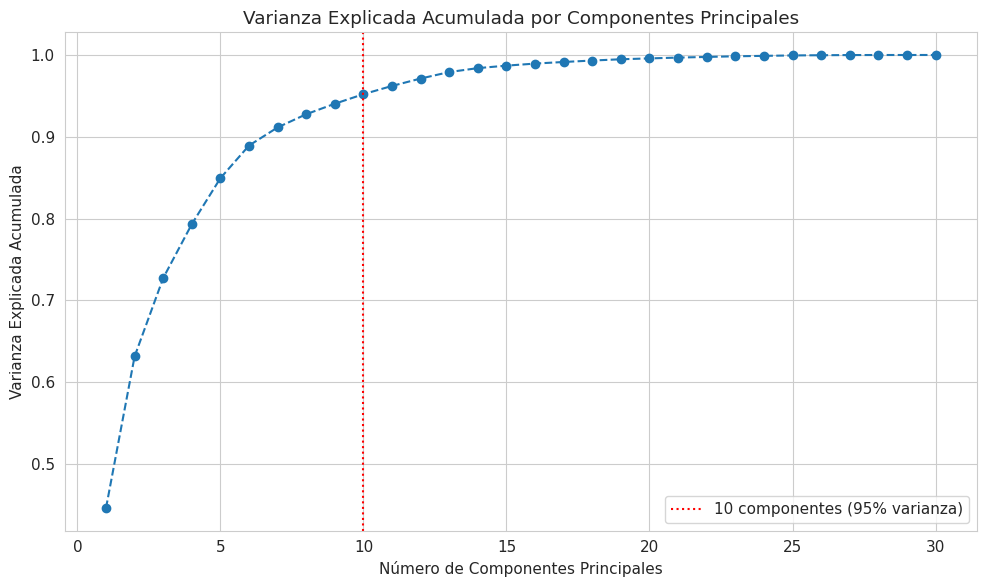

Dimensiones de X_train_pca: (455, 2)
Dimensiones de X_test_pca: (114, 2)


In [ ]:
from sklearn.decomposition import PCA

# Ajustar PCA a los datos de entrenamiento estandarizados
pca = PCA(random_state=SEED)
pca.fit(X_train_std)

# Calcular la varianza explicada acumulada
explained_variance_ratio_cumsum = np.cumsum(pca.explained_variance_ratio_)

# Determinar el número de componentes para explicar el 95% de la varianza
n_components_95 = np.argmax(explained_variance_ratio_cumsum >= 0.95) + 1

print(f"Número de componentes necesarios para explicar el 95% de la varianza: {n_components_95}")

# Graficar la varianza explicada por cada componente y la varianza acumulada
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_ratio_cumsum) + 1), explained_variance_ratio_cumsum, marker='o', linestyle='--')
plt.title('Varianza Explicada Acumulada por Componentes Principales')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Explicada Acumulada')
plt.axvline(x=n_components_95, color='r', linestyle=':', label=f'{n_components_95} componentes (95% varianza)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "06_pca_explained_variance.png", dpi=120)
plt.show()

# Transformar los datos de entrenamiento y prueba usando el número óptimo de componentes (2 para las clases benigno y maligno)
pca_final = PCA(n_components=2, random_state=SEED)
X_train_pca = pca_final.fit_transform(X_train_std)
X_test_pca = pca_final.transform(X_test_std)

print(f"Dimensiones de X_train_pca: {X_train_pca.shape}")
print(f"Dimensiones de X_test_pca: {X_test_pca.shape}")

## 15. Algoritmo 2 LDA Análisis Discriminante Lineal

Dimensiones de X_train_lda: (455, 1)
Dimensiones de X_test_lda: (114, 1)


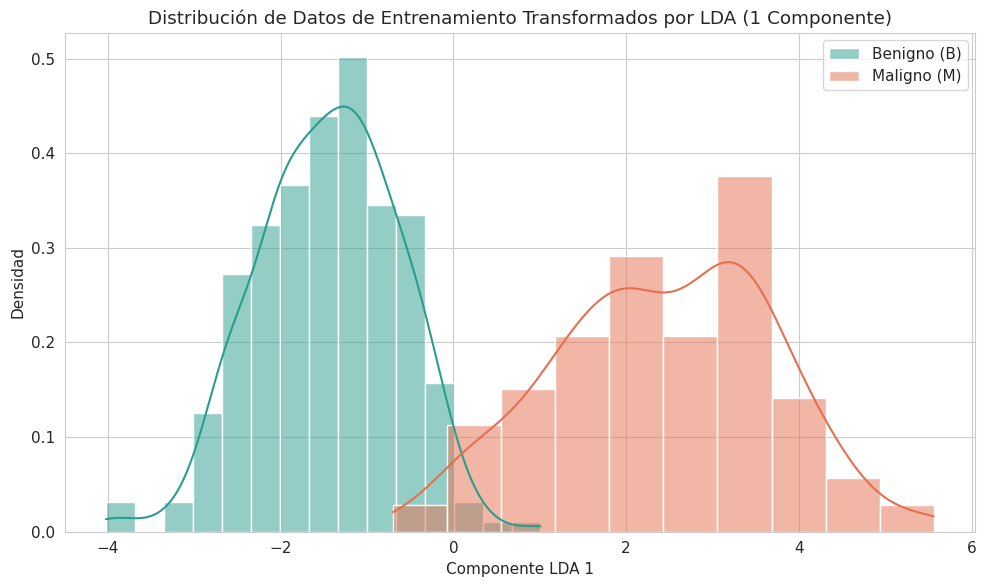

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# 1. Inicializar LDA. Para un problema de 2 clases, LDA puede encontrar a lo sumo 1 componente.
lda = LinearDiscriminantAnalysis(n_components=1)

# 2. Ajustar LDA a los datos de entrenamiento estandarizados y las etiquetas de clase
# LDA es un método supervisado, por lo que necesita y_train
lda.fit(X_train_std, y_train)

# 3. Transformar los datos de entrenamiento y prueba
X_train_lda = lda.transform(X_train_std)
X_test_lda = lda.transform(X_test_std)

print(f"Dimensiones de X_train_lda: {X_train_lda.shape}")
print(f"Dimensiones de X_test_lda: {X_test_lda.shape}")

# Mostramos los datos a traves de un histograma
plt.figure(figsize=(10, 6))
for cls, color, label_name in zip([0, 1], ['#2a9d8f', '#e76f51'], [LABELS[0], LABELS[1]]):
    sns.histplot(X_train_lda[y_train == cls].flatten(), color=color, label=label_name, kde=True, stat='density', alpha=0.5)

plt.title('Distribución de Datos de Entrenamiento Transformados por LDA (1 Componente)')
plt.xlabel('Componente LDA 1')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(OUT_DIR / "08_lda_visualization.png", dpi=120)
plt.show()

## Modelo 1 Regresión Logisitica

Aplicación de la reducción de dimensiones (PCA y LDA)

### Entrenando y Ajustando Modelos de Clasificación (Regresión Logística con PCA y LDA) ###

--- Entrenando Regresión Logística (Standard Features) ---
Mejores parámetros: {'C': 0.01, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'liblinear'}
Métricas en Test:


,Modelo,Versión,Accuracy,Precision,Recall,F1,AUC
0,Regresión Logística,Standard Features,0.973684,0.933333,1.0,0.965517,0.996032


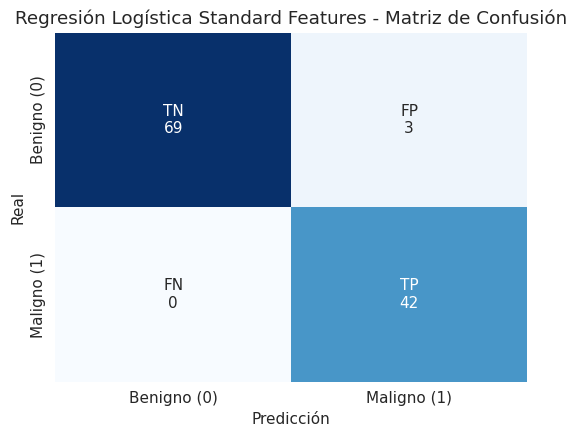

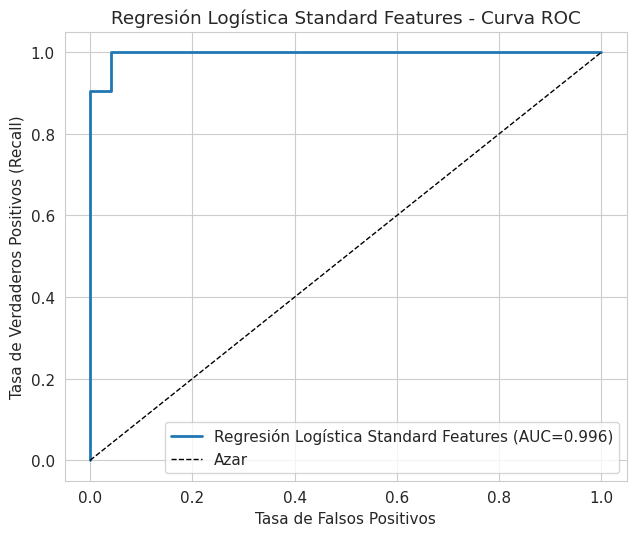

Modelo guardado en /models/lr_std.joblib (Tamaño: 0.00 MB)
--------------------------------------------------
--- Entrenando Regresión Logística (PCA Features) ---
Mejores parámetros: {'C': 0.1, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'liblinear'}
Métricas en Test:


,Modelo,Versión,Accuracy,Precision,Recall,F1,AUC
0,Regresión Logística,PCA Features,0.982456,0.97619,0.97619,0.97619,0.996032


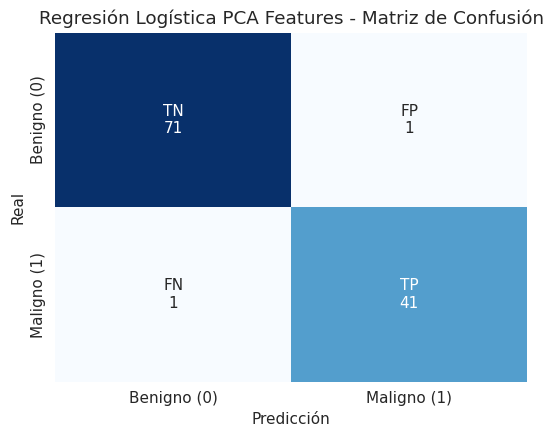

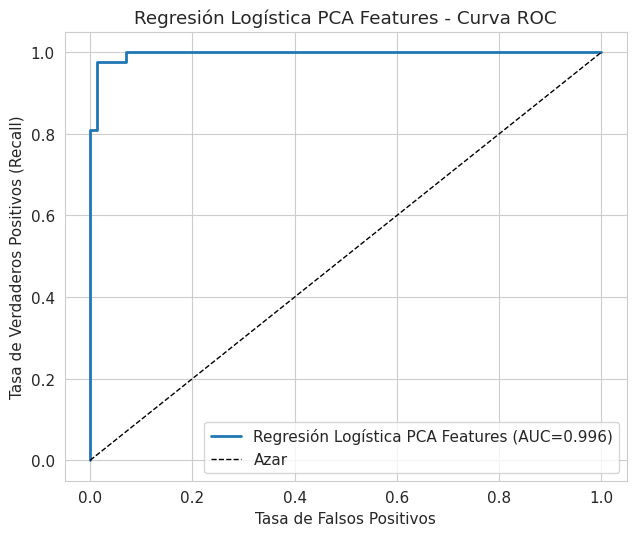

Modelo guardado en /models/lr_pca.joblib (Tamaño: 0.00 MB)
--------------------------------------------------
--- Entrenando Regresión Logística (LDA Features) ---
Mejores parámetros: {'C': 0.01, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'liblinear'}
Métricas en Test:


,Modelo,Versión,Accuracy,Precision,Recall,F1,AUC
0,Regresión Logística,LDA Features,0.938596,0.87234,0.97619,0.921348,0.997024


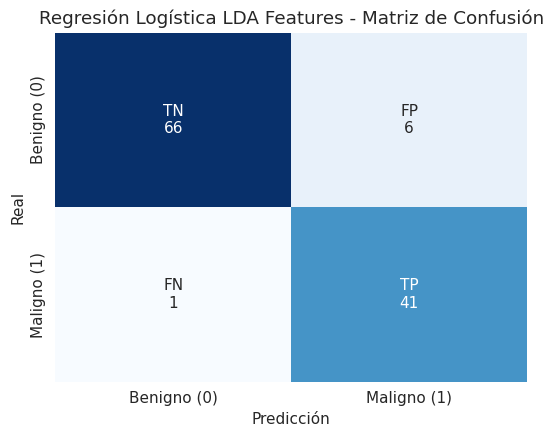

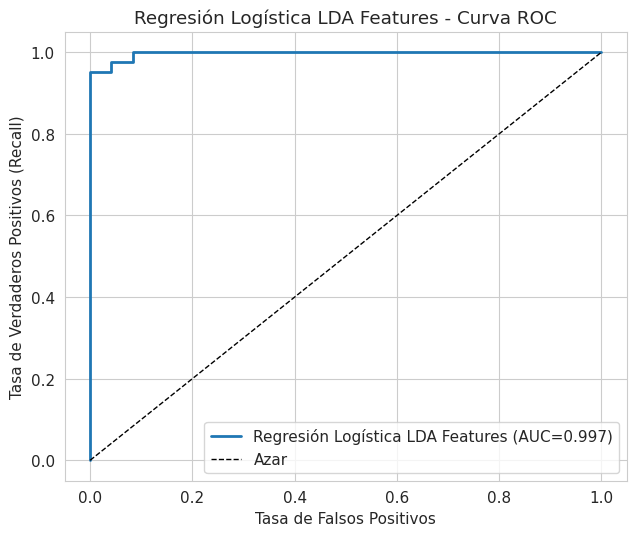

Modelo guardado en /models/lr_lda.joblib (Tamaño: 0.00 MB)
--------------------------------------------------


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

print("### Entrenando y Ajustando Modelos de Clasificación (Regresión Logística con PCA y LDA) ###\n")

# --- Algoritmo 1: Regresión Logística ---
lr_params = {
    'penalty': ['l1', 'l2'],
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear'],
    'max_iter': [1000]
}

# 1. Regresión Logística sobre Características Originales (Escaladas)
lr_std_model = train_and_evaluate_classifier(
    LogisticRegression(random_state=SEED), lr_params,
    X_train_std, y_train, X_test_std, y_test,
    "Regresión Logística", "Standard Features", "lr_std"
)

# 2. Regresión Logística sobre Características PCA
lr_pca_model = train_and_evaluate_classifier(
    LogisticRegression(random_state=SEED), lr_params,
    X_train_pca, y_train, X_test_pca, y_test,
    "Regresión Logística", "PCA Features", "lr_pca"
)

# 3. Regresión Logística sobre Características LDA
lr_lda_model = train_and_evaluate_classifier(
    LogisticRegression(random_state=SEED), lr_params,
    X_train_lda, y_train, X_test_lda, y_test,
    "Regresión Logística", "LDA Features", "lr_lda"
)

## Modelo 2 KNN

Aplicación de la reducción de dimensiones (PCA y LDA)

### Entrenando y Ajustando Modelos de Clasificación (KNN con PCA y LDA) ###

--- Entrenando KNN (Standard Features) ---
Mejores parámetros: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
Métricas en Test:


,Modelo,Versión,Accuracy,Precision,Recall,F1,AUC
0,KNN,Standard Features,0.938596,0.972973,0.857143,0.911392,0.982474


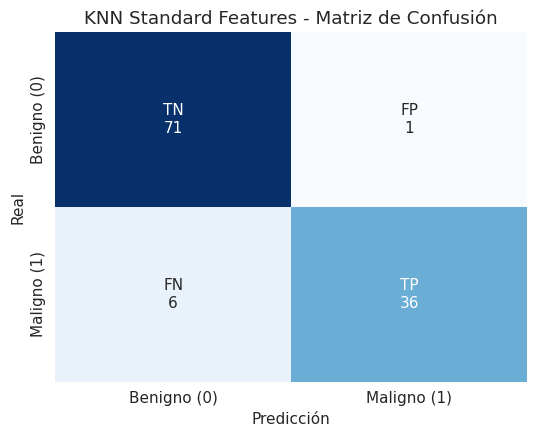

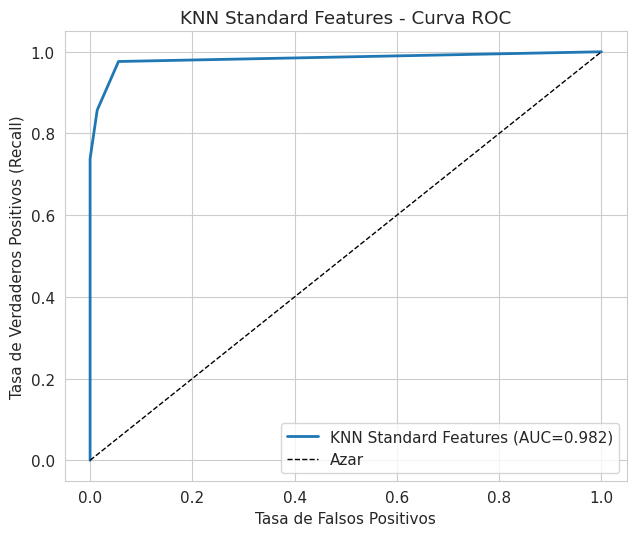

Modelo guardado en /models/knn_std.joblib (Tamaño: 0.11 MB)
--------------------------------------------------
--- Entrenando KNN (PCA Features) ---
Mejores parámetros: {'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'uniform'}
Métricas en Test:


,Modelo,Versión,Accuracy,Precision,Recall,F1,AUC
0,KNN,PCA Features,0.95614,0.974359,0.904762,0.938272,0.988591


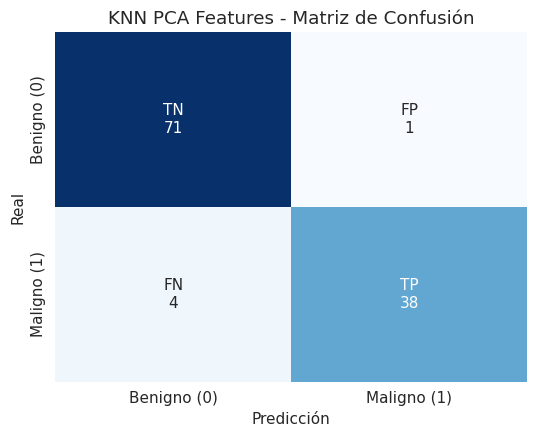

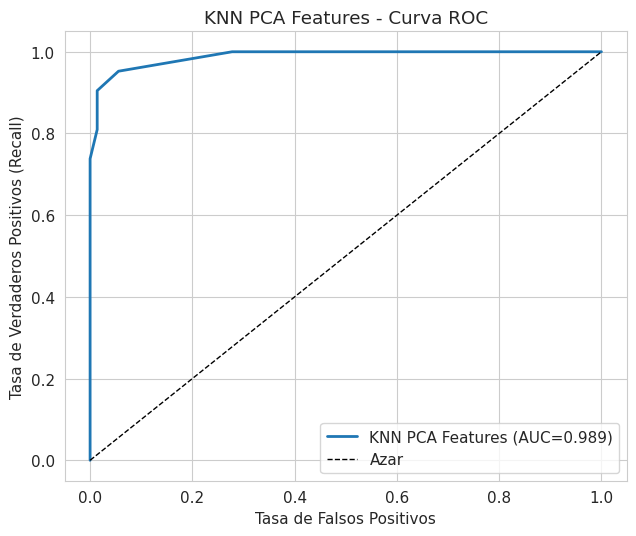

Modelo guardado en /models/knn_pca.joblib (Tamaño: 0.02 MB)
--------------------------------------------------
--- Entrenando KNN (LDA Features) ---
Mejores parámetros: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'uniform'}
Métricas en Test:


,Modelo,Versión,Accuracy,Precision,Recall,F1,AUC
0,KNN,LDA Features,0.95614,0.930233,0.952381,0.941176,0.996528


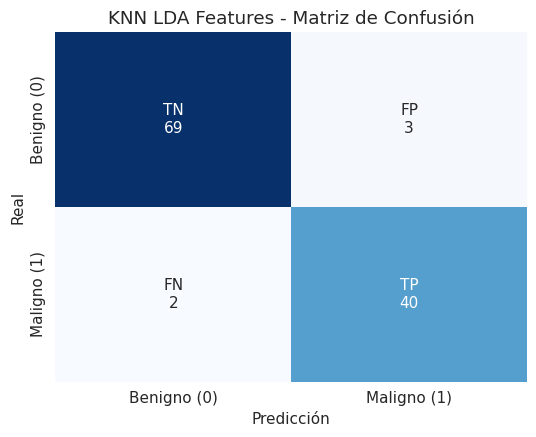

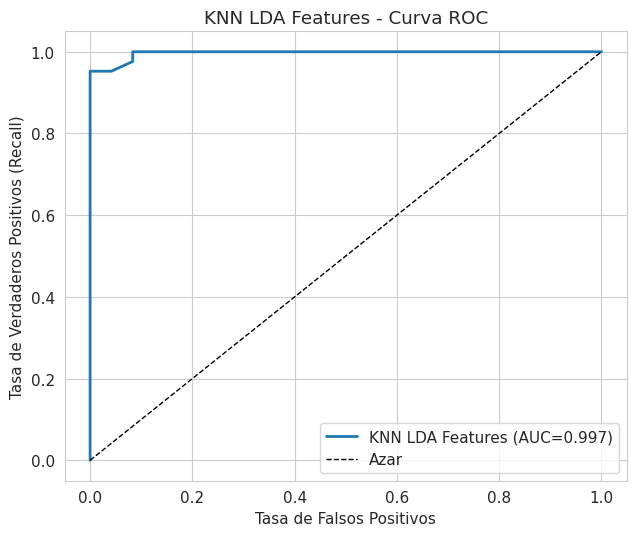

Modelo guardado en /models/knn_lda.joblib (Tamaño: 0.02 MB)
--------------------------------------------------


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB


print("### Entrenando y Ajustando Modelos de Clasificación (KNN con PCA y LDA) ###\n")

# --- Algoritmo 2: K-Nearest Neighbors (KNN) ---
knn_params = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'minkowski']
}

# 1. KNN sobre Características Originales (Escaladas)
knn_std_model = train_and_evaluate_classifier(
    KNeighborsClassifier(), knn_params,
    X_train_std, y_train, X_test_std, y_test,
    "KNN", "Standard Features", "knn_std"
)

# 2. KNN sobre Características PCA
knn_pca_model = train_and_evaluate_classifier(
    KNeighborsClassifier(), knn_params,
    X_train_pca, y_train, X_test_pca, y_test,
    "KNN", "PCA Features", "knn_pca"
)

# 3. KNN sobre Características LDA
knn_lda_model = train_and_evaluate_classifier(
    KNeighborsClassifier(), knn_params,
    X_train_lda, y_train, X_test_lda, y_test,
    "KNN", "LDA Features", "knn_lda"
)

## Modelo 3 Naive Bayes Gaussiano

Aplicación de la reducción de dimensiones (PCA y LDA)

### Entrenando y Ajustando Modelos de Clasificación (Naive Bayes con PCA y LDA) ###

--- Entrenando Naive Bayes (Standard Features) ---
Mejores parámetros: {'var_smoothing': np.float64(0.0023101297000831605)}
Métricas en Test:


,Modelo,Versión,Accuracy,Precision,Recall,F1,AUC
0,Naive Bayes,Standard Features,0.921053,0.923077,0.857143,0.888889,0.989087


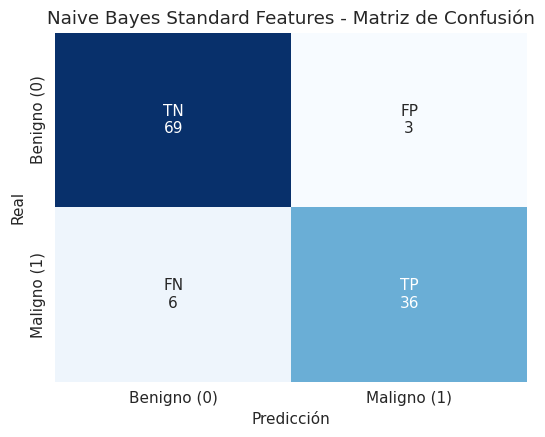

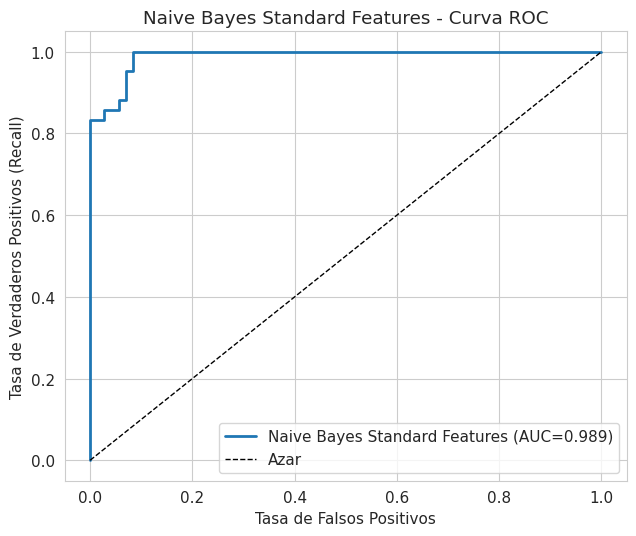

Modelo guardado en /models/nb_std.joblib (Tamaño: 0.00 MB)
--------------------------------------------------
--- Entrenando Naive Bayes (PCA Features) ---
Mejores parámetros: {'var_smoothing': np.float64(0.02310129700083159)}
Métricas en Test:


,Modelo,Versión,Accuracy,Precision,Recall,F1,AUC
0,Naive Bayes,PCA Features,0.894737,0.916667,0.785714,0.846154,0.98082


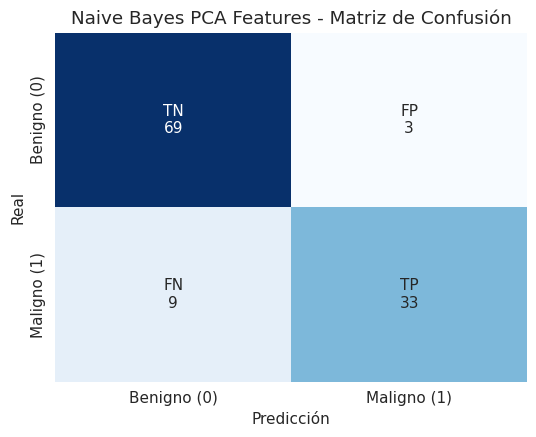

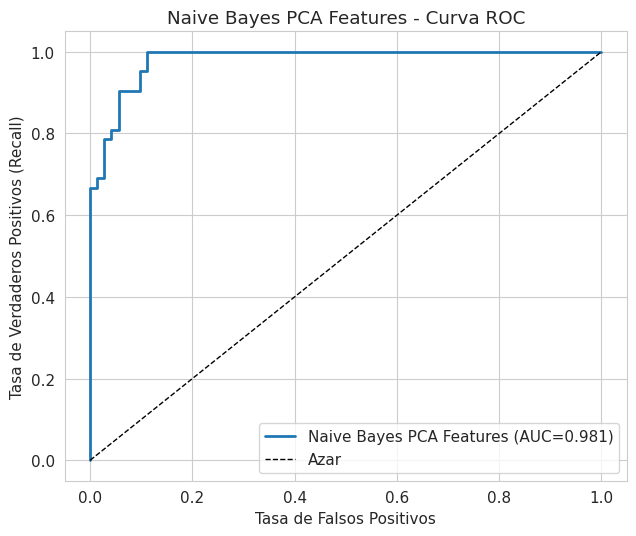

Modelo guardado en /models/nb_pca.joblib (Tamaño: 0.00 MB)
--------------------------------------------------
--- Entrenando Naive Bayes (LDA Features) ---
Mejores parámetros: {'var_smoothing': np.float64(0.012328467394420659)}
Métricas en Test:


,Modelo,Versión,Accuracy,Precision,Recall,F1,AUC
0,Naive Bayes,LDA Features,0.982456,1.0,0.952381,0.97561,0.997024


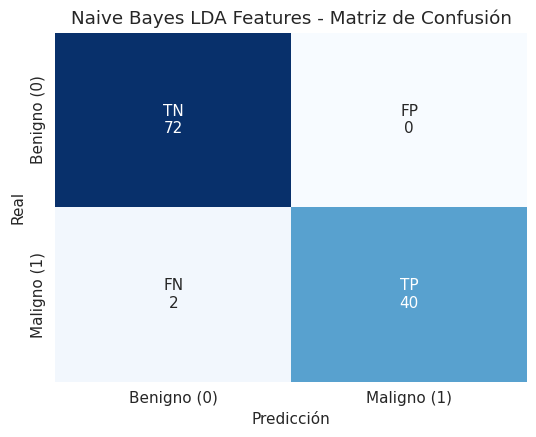

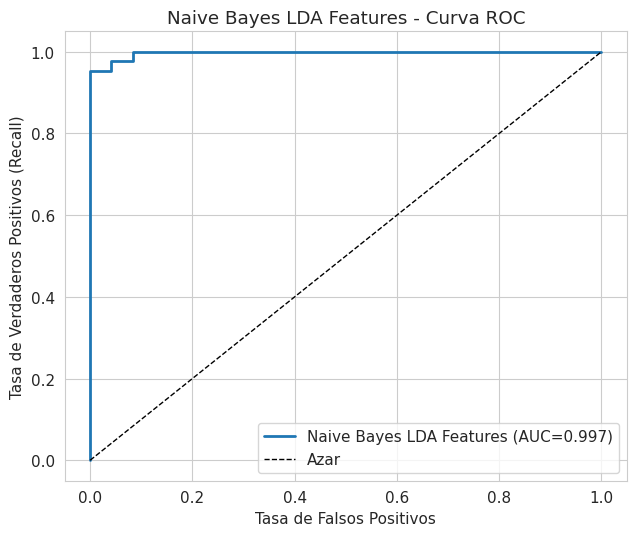

Modelo guardado en /models/nb_lda.joblib (Tamaño: 0.00 MB)
--------------------------------------------------


In [ ]:
print("### Entrenando y Ajustando Modelos de Clasificación (Naive Bayes con PCA y LDA) ###\n")

# El único parámetro relevante para GaussianNB es 'var_smoothing'
nb_params = {
    'var_smoothing': np.logspace(0, -9, num=100)
}

# 1. Naive Bayes sobre Características Originales (Escaladas)
nb_std_model = train_and_evaluate_classifier(
    GaussianNB(), nb_params,
    X_train_std, y_train, X_test_std, y_test,
    "Naive Bayes", "Standard Features", "nb_std"
)

# 2. Naive Bayes sobre Características PCA
nb_pca_model = train_and_evaluate_classifier(
    GaussianNB(), nb_params,
    X_train_pca, y_train, X_test_pca, y_test,
    "Naive Bayes", "PCA Features", "nb_pca"
)

# 3. Naive Bayes sobre Características LDA
nb_lda_model = train_and_evaluate_classifier(
    GaussianNB(), nb_params,
    X_train_lda, y_train, X_test_lda, y_test,
    "Naive Bayes", "LDA Features", "nb_lda"
)

## Modelo 4 Arbol de Decisión

Aplicación de la reducción de dimensiones (PCA y LDA)

### Entrenando y Ajustando Modelos de Clasificación (Árbol de Decisión con Standard, PCA y LDA) ###

--- Entrenando Árbol de Decisión (Standard Features) ---
Mejores parámetros: {'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 5}
Métricas en Test:


,Modelo,Versión,Accuracy,Precision,Recall,F1,AUC
0,Árbol de Decisión,Standard Features,0.947368,0.95,0.904762,0.926829,0.946263


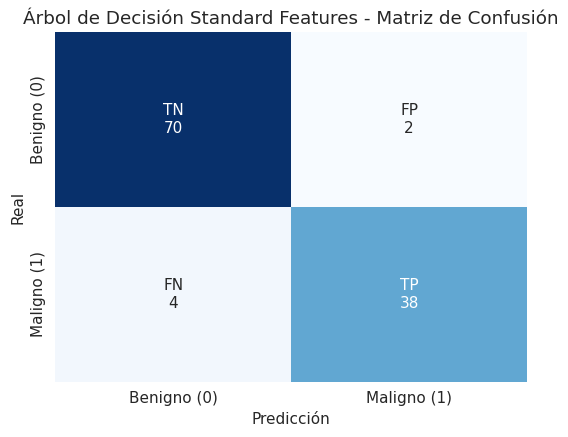

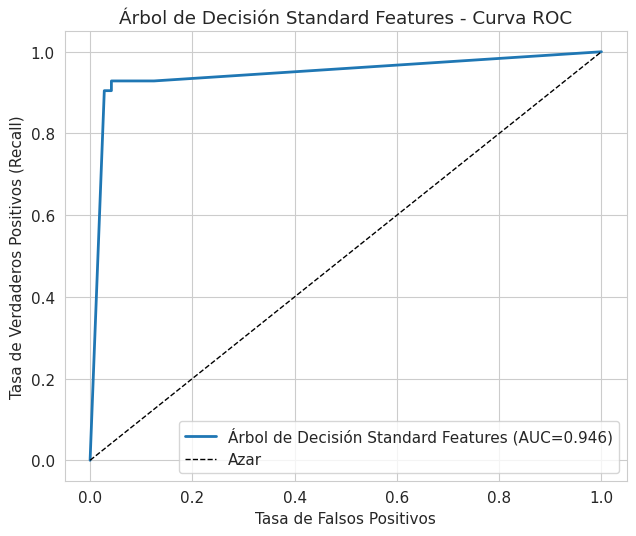

Modelo guardado en /models/dt_std.joblib (Tamaño: 0.00 MB)
--------------------------------------------------
--- Entrenando Árbol de Decisión (PCA Features) ---
Mejores parámetros: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Métricas en Test:


,Modelo,Versión,Accuracy,Precision,Recall,F1,AUC
0,Árbol de Decisión,PCA Features,0.929825,0.904762,0.904762,0.904762,0.976025


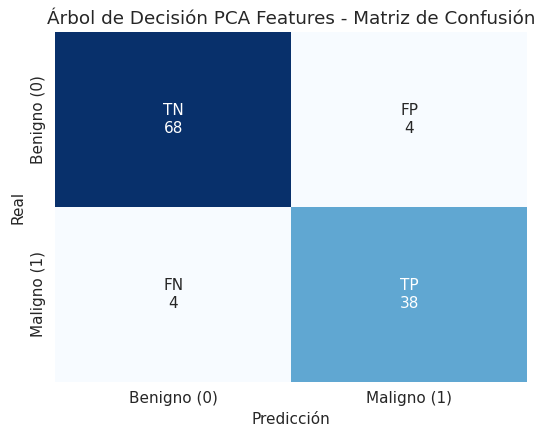

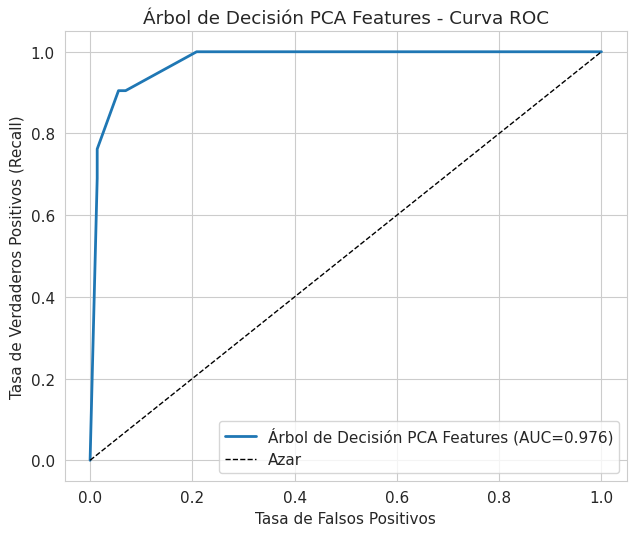

Modelo guardado en /models/dt_pca.joblib (Tamaño: 0.00 MB)
--------------------------------------------------
--- Entrenando Árbol de Decisión (LDA Features) ---
Mejores parámetros: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Métricas en Test:


,Modelo,Versión,Accuracy,Precision,Recall,F1,AUC
0,Árbol de Decisión,LDA Features,0.938596,0.87234,0.97619,0.921348,0.988591


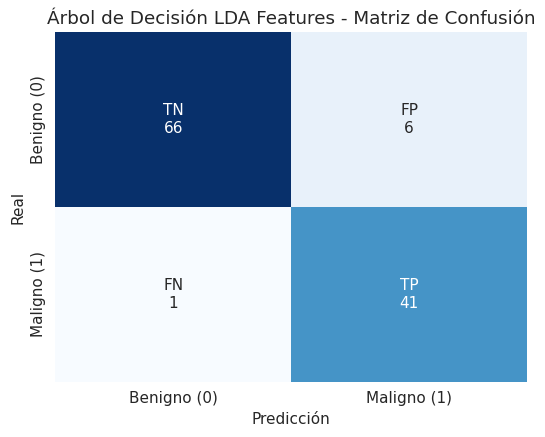

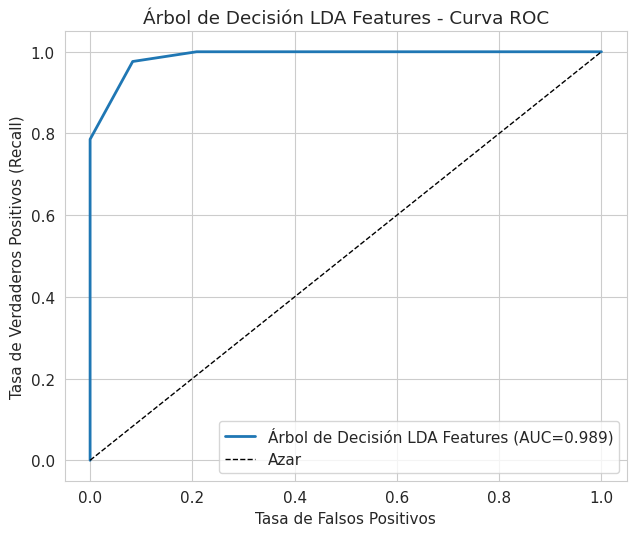

Modelo guardado en /models/dt_lda.joblib (Tamaño: 0.00 MB)
--------------------------------------------------


In [ ]:
from sklearn.tree import DecisionTreeClassifier

print("### Entrenando y Ajustando Modelos de Clasificación (Árbol de Decisión con Standard, PCA y LDA) ###\n")

# --- Algoritmo 4: Árbol de Decisión ---
dt_params = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# 1. Árbol de Decisión sobre Características Originales (Escaladas)
dt_std_model = train_and_evaluate_classifier(
    DecisionTreeClassifier(random_state=SEED), dt_params,
    X_train_std, y_train, X_test_std, y_test,
    "Árbol de Decisión", "Standard Features", "dt_std"
)

# 2. Árbol de Decisión sobre Características PCA
dt_pca_model = train_and_evaluate_classifier(
    DecisionTreeClassifier(random_state=SEED), dt_params,
    X_train_pca, y_train, X_test_pca, y_test,
    "Árbol de Decisión", "PCA Features", "dt_pca"
)

# 3. Árbol de Decisión sobre Características LDA
dt_lda_model = train_and_evaluate_classifier(
    DecisionTreeClassifier(random_state=SEED), dt_params,
    X_train_lda, y_train, X_test_lda, y_test,
    "Árbol de Decisión", "LDA Features", "dt_lda"
)

## Modelo 5 Bosque Randómico

Aplicación de la reducción de dimensiones (PCA y LDA)

### Entrenando y Ajustando Modelos de Clasificación (Bosque Randómico con Standard, PCA y LDA) ###

--- Entrenando Bosque Randómico (Standard Features) ---
Mejores parámetros: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Métricas en Test:


,Modelo,Versión,Accuracy,Precision,Recall,F1,AUC
0,Bosque Randómico,Standard Features,0.964912,1.0,0.904762,0.95,0.997024


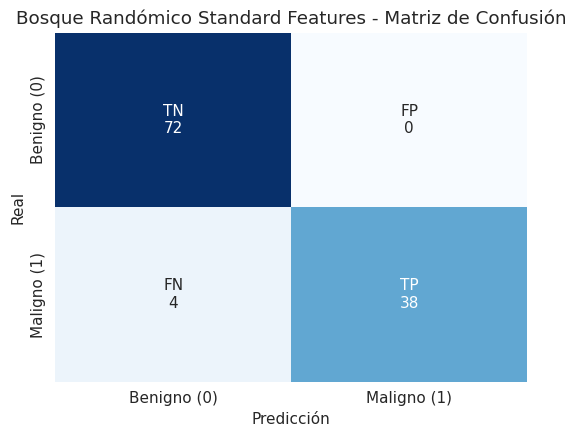

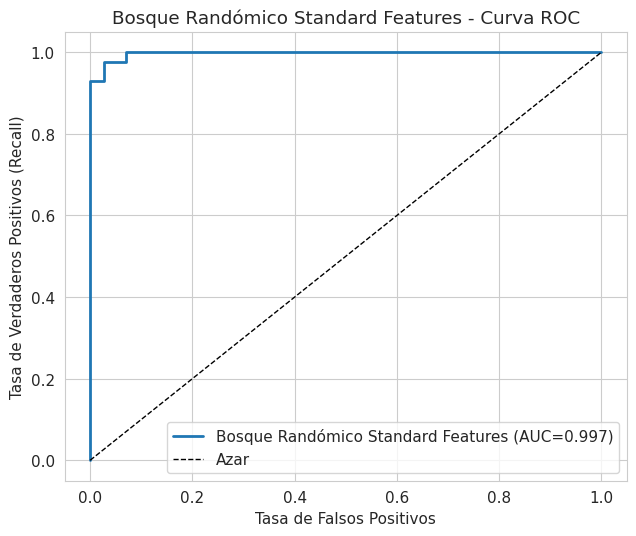

Modelo guardado en /models/rf_std.joblib (Tamaño: 0.24 MB)
--------------------------------------------------
--- Entrenando Bosque Randómico (PCA Features) ---
Mejores parámetros: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Métricas en Test:


,Modelo,Versión,Accuracy,Precision,Recall,F1,AUC
0,Bosque Randómico,PCA Features,0.95614,0.974359,0.904762,0.938272,0.991071


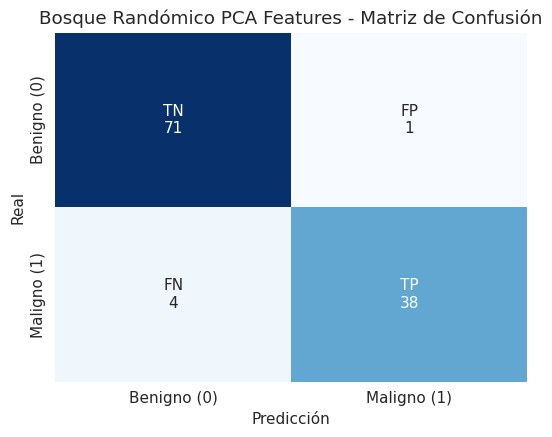

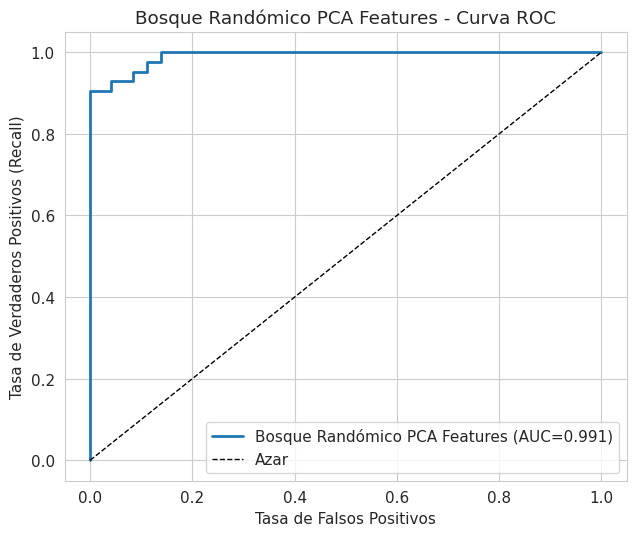

Modelo guardado en /models/rf_pca.joblib (Tamaño: 0.61 MB)
--------------------------------------------------
--- Entrenando Bosque Randómico (LDA Features) ---
Mejores parámetros: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 50}
Métricas en Test:


,Modelo,Versión,Accuracy,Precision,Recall,F1,AUC
0,Bosque Randómico,LDA Features,0.947368,0.909091,0.952381,0.930233,0.99537


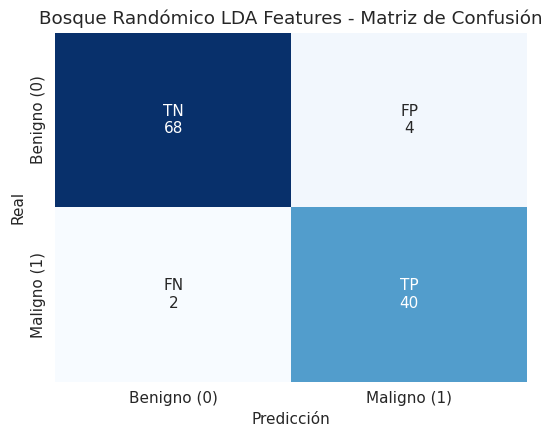

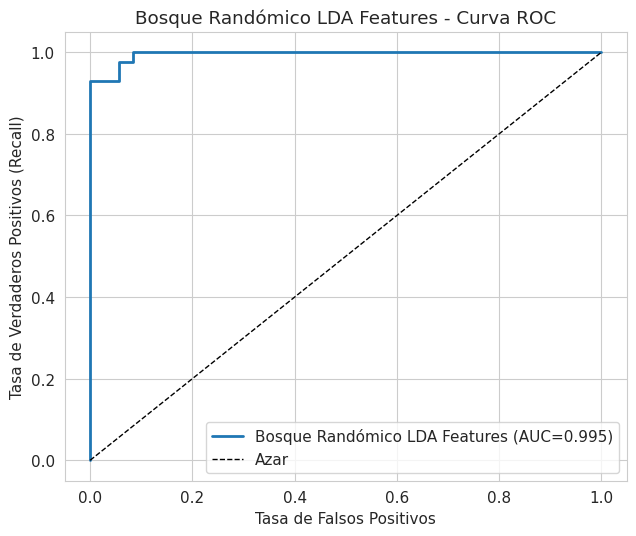

Modelo guardado en /models/rf_lda.joblib (Tamaño: 0.08 MB)
--------------------------------------------------


In [ ]:
from sklearn.ensemble import RandomForestClassifier

print("### Entrenando y Ajustando Modelos de Clasificación (Bosque Randómico con Standard, PCA y LDA) ###\n")

# --- Algoritmo 5: Bosque Randómico ---
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'criterion': ['gini', 'entropy']
}

# 1. Bosque Randómico sobre Características Originales (Escaladas)
rf_std_model = train_and_evaluate_classifier(
    RandomForestClassifier(random_state=SEED), rf_params,
    X_train_std, y_train, X_test_std, y_test,
    "Bosque Randómico", "Standard Features", "rf_std"
)

# 2. Bosque Randómico sobre Características PCA
rf_pca_model = train_and_evaluate_classifier(
    RandomForestClassifier(random_state=SEED), rf_params,
    X_train_pca, y_train, X_test_pca, y_test,
    "Bosque Randómico", "PCA Features", "rf_pca"
)

# 3. Bosque Randómico sobre Características LDA
rf_lda_model = train_and_evaluate_classifier(
    RandomForestClassifier(random_state=SEED), rf_params,
    X_train_lda, y_train, X_test_lda, y_test,
    "Bosque Randómico", "LDA Features", "rf_lda"
)

## Modelo 6 Máquina de Soporte de Vectores

Aplicación de la reducción de dimensiones (PCA y LDA)

### Entrenando y Ajustando Modelos de Clasificación (Máquina de Soporte Vectorial con Standard, PCA y LDA) ###

--- Entrenando SVM (Standard Features) ---
Mejores parámetros: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Métricas en Test:


,Modelo,Versión,Accuracy,Precision,Recall,F1,AUC
0,SVM,Standard Features,0.973684,1.0,0.928571,0.962963,0.992725


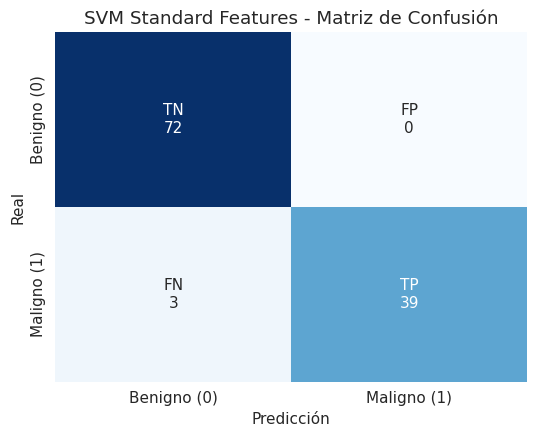

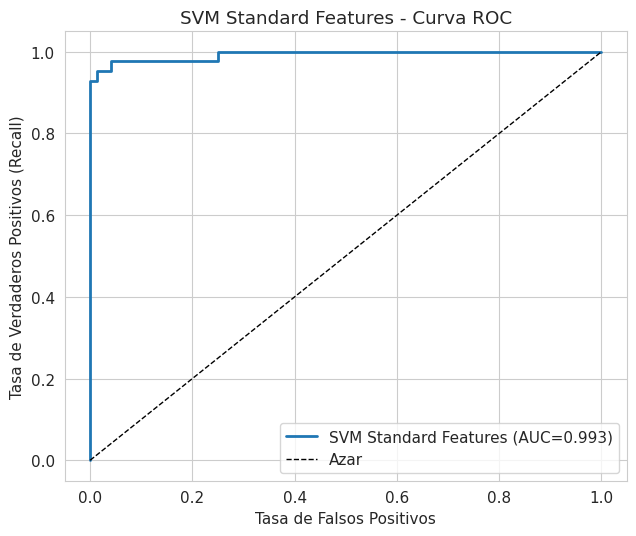

Modelo guardado en /models/svm_std.joblib (Tamaño: 0.02 MB)
--------------------------------------------------
--- Entrenando SVM (PCA Features) ---
Mejores parámetros: {'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}
Métricas en Test:


,Modelo,Versión,Accuracy,Precision,Recall,F1,AUC
0,SVM,PCA Features,0.95614,0.974359,0.904762,0.938272,0.98082


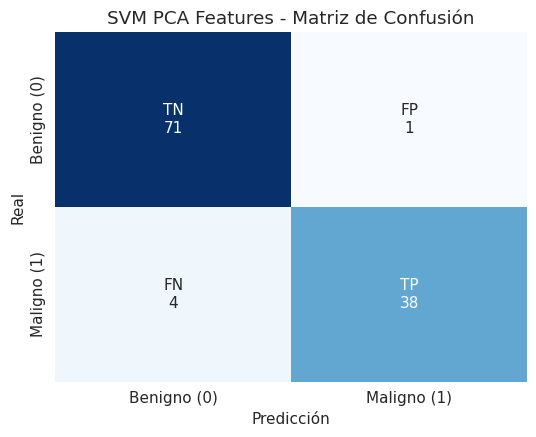

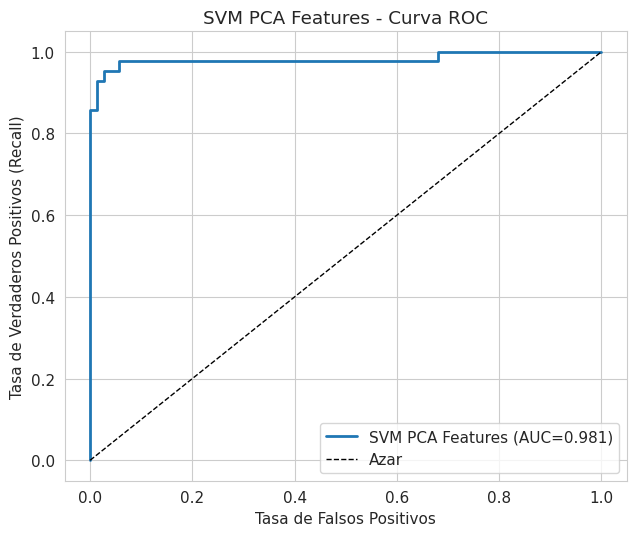

Modelo guardado en /models/svm_pca.joblib (Tamaño: 0.01 MB)
--------------------------------------------------
--- Entrenando SVM (LDA Features) ---
Mejores parámetros: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
Métricas en Test:


,Modelo,Versión,Accuracy,Precision,Recall,F1,AUC
0,SVM,LDA Features,0.964912,0.952381,0.952381,0.952381,0.997024


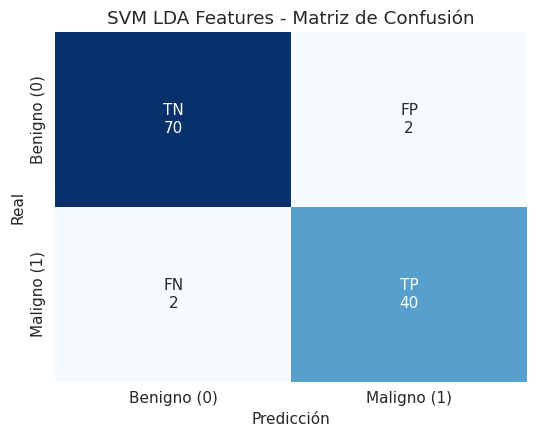

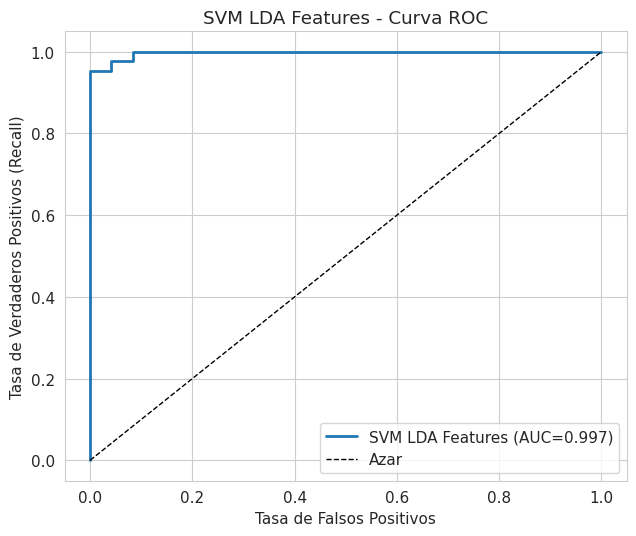

Modelo guardado en /models/svm_lda.joblib (Tamaño: 0.00 MB)
--------------------------------------------------


In [ ]:
from sklearn.svm import SVC

print("### Entrenando y Ajustando Modelos de Clasificación (Máquina de Soporte Vectorial con Standard, PCA y LDA) ###\n")

# --- Algoritmo 6: Máquina de Soporte Vectorial (SVM) ---
svm_params = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

# 1. SVM sobre Características Originales (Escaladas)
svm_std_model = train_and_evaluate_classifier(
    SVC(random_state=SEED, probability=True), svm_params,
    X_train_std, y_train, X_test_std, y_test,
    "SVM", "Standard Features", "svm_std"
)

# 2. SVM sobre Características PCA
svm_pca_model = train_and_evaluate_classifier(
    SVC(random_state=SEED, probability=True), svm_params,
    X_train_pca, y_train, X_test_pca, y_test,
    "SVM", "PCA Features", "svm_pca"
)

# 3. SVM sobre Características LDA
svm_lda_model = train_and_evaluate_classifier(
    SVC(random_state=SEED, probability=True), svm_params,
    X_train_lda, y_train, X_test_lda, y_test,
    "SVM", "LDA Features", "svm_lda"
)

## Modelo 7 Clasificador de Gradiente Mejorado

Aplicación de la reducción de dimensiones (PCA y LDA)

### Entrenando y Ajustando Modelos de Clasificación (Gradient Boosting con Standard, PCA y LDA) ###

--- Entrenando Gradient Boosting (Standard Features) ---
Mejores parámetros: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
Métricas en Test:


,Modelo,Versión,Accuracy,Precision,Recall,F1,AUC
0,Gradient Boosting,Standard Features,0.964912,1.0,0.904762,0.95,0.997685


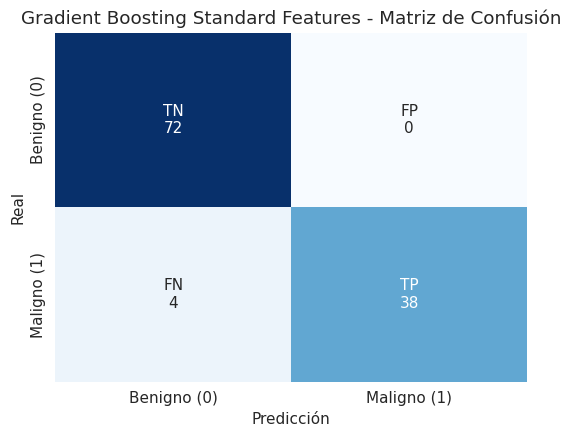

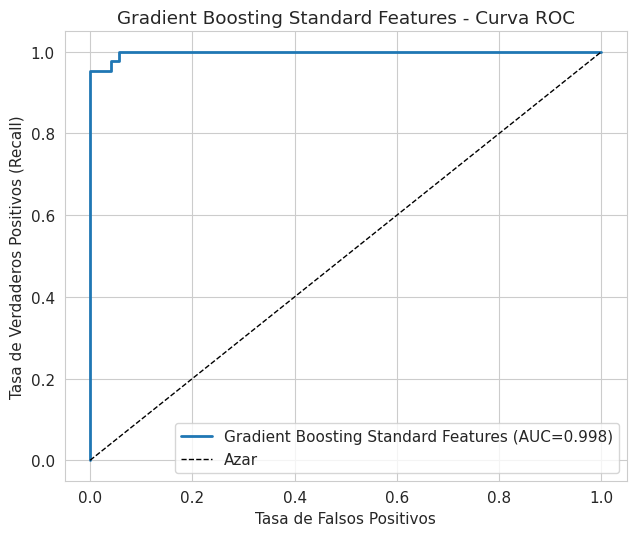

Modelo guardado en /models/gb_std.joblib (Tamaño: 1.17 MB)
--------------------------------------------------
--- Entrenando Gradient Boosting (PCA Features) ---
Mejores parámetros: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50, 'subsample': 1.0}
Métricas en Test:


,Modelo,Versión,Accuracy,Precision,Recall,F1,AUC
0,Gradient Boosting,PCA Features,0.95614,0.974359,0.904762,0.938272,0.997024


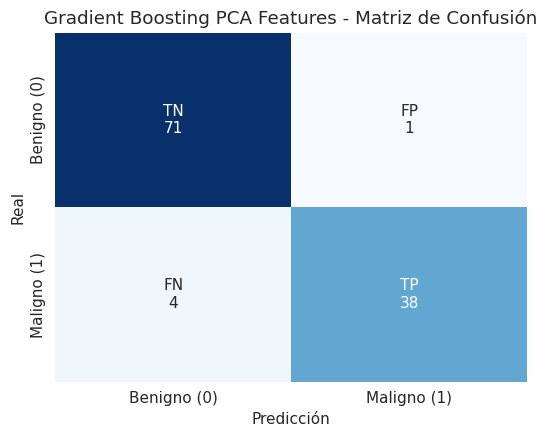

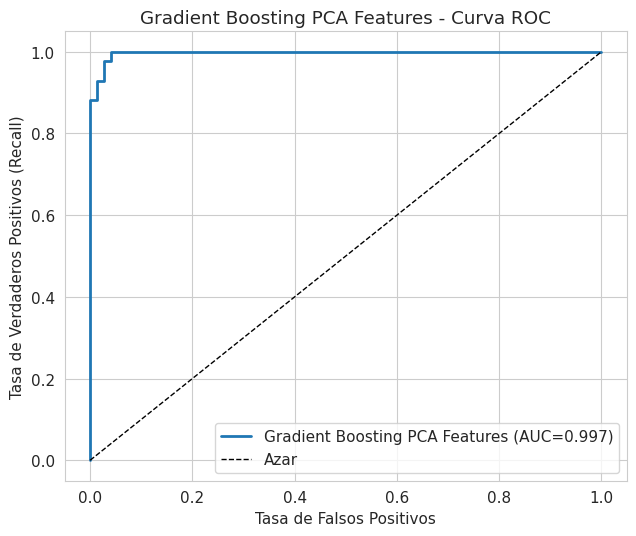

Modelo guardado en /models/gb_pca.joblib (Tamaño: 0.07 MB)
--------------------------------------------------
--- Entrenando Gradient Boosting (LDA Features) ---
Mejores parámetros: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50, 'subsample': 1.0}
Métricas en Test:


,Modelo,Versión,Accuracy,Precision,Recall,F1,AUC
0,Gradient Boosting,LDA Features,0.95614,0.911111,0.97619,0.942529,0.998347


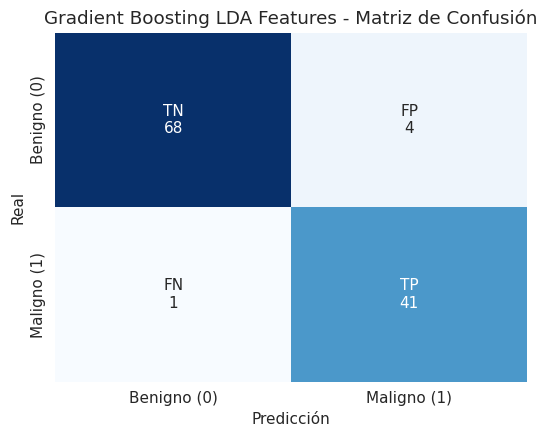

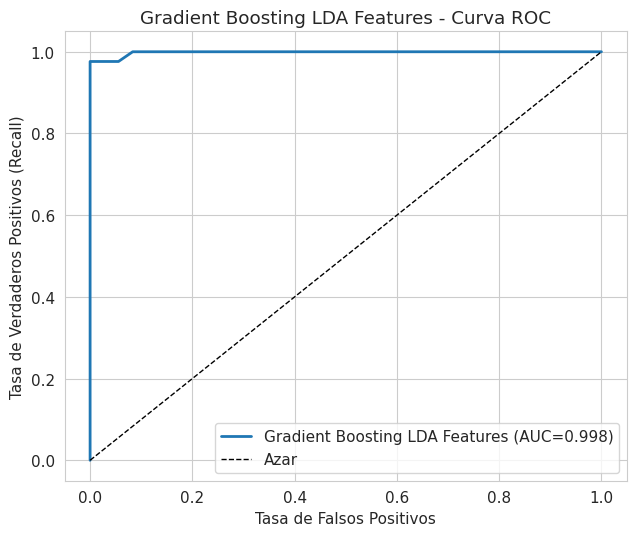

Modelo guardado en /models/gb_lda.joblib (Tamaño: 0.07 MB)
--------------------------------------------------


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

print("### Entrenando y Ajustando Modelos de Clasificación (Gradient Boosting con Standard, PCA y LDA) ###\n")

# --- Algoritmo 7: Gradient Boosting Classifier ---
gb_params = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}

# 1. Gradient Boosting sobre Características Originales (Escaladas)
gb_std_model = train_and_evaluate_classifier(
    GradientBoostingClassifier(random_state=SEED), gb_params,
    X_train_std, y_train, X_test_std, y_test,
    "Gradient Boosting", "Standard Features", "gb_std"
)

# 2. Gradient Boosting sobre Características PCA
gb_pca_model = train_and_evaluate_classifier(
    GradientBoostingClassifier(random_state=SEED), gb_params,
    X_train_pca, y_train, X_test_pca, y_test,
    "Gradient Boosting", "PCA Features", "gb_pca"
)

# 3. Gradient Boosting sobre Características LDA
gb_lda_model = train_and_evaluate_classifier(
    GradientBoostingClassifier(random_state=SEED), gb_params,
    X_train_lda, y_train, X_test_lda, y_test,
    "Gradient Boosting", "LDA Features", "gb_lda"
)

## Modelo 8 Red Neuronal

Aplicación de la reducción de dimensiones (PCA y LDA)

### Entrenando y Ajustando Modelos de Clasificación (Red Neuronal con Standard, PCA y LDA) ###

--- Entrenando Red Neuronal (Standard Features) ---
Mejores parámetros: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (100,), 'learning_rate_init': 0.001, 'max_iter': 500, 'solver': 'adam'}
Métricas en Test:


,Modelo,Versión,Accuracy,Precision,Recall,F1,AUC
0,Red Neuronal,Standard Features,0.964912,1.0,0.904762,0.95,0.993717


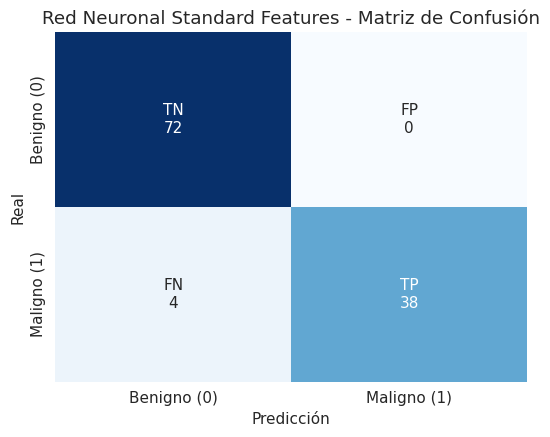

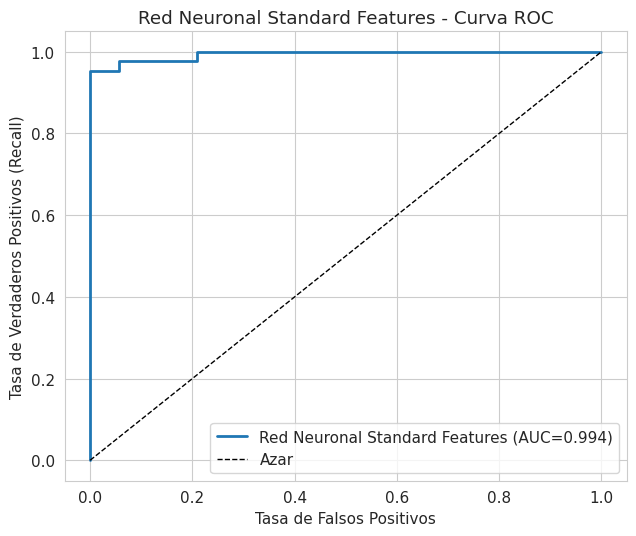

Modelo guardado en /models/mlp_std.joblib (Tamaño: 0.11 MB)
--------------------------------------------------
--- Entrenando Red Neuronal (PCA Features) ---
Mejores parámetros: {'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (100,), 'learning_rate_init': 0.01, 'max_iter': 500, 'solver': 'adam'}
Métricas en Test:


,Modelo,Versión,Accuracy,Precision,Recall,F1,AUC
0,Red Neuronal,PCA Features,0.964912,0.975,0.928571,0.95122,0.996362


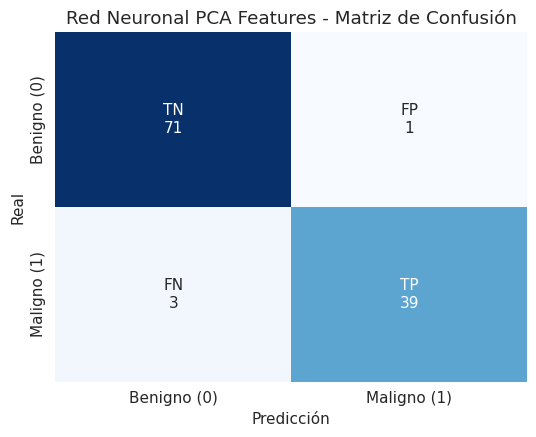

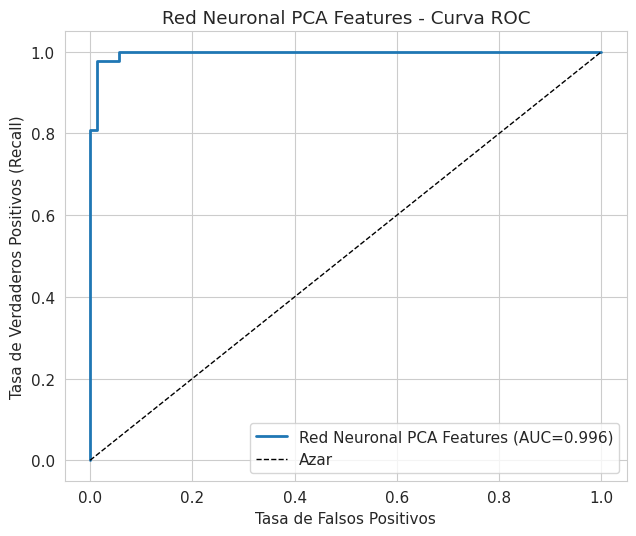

Modelo guardado en /models/mlp_pca.joblib (Tamaño: 0.02 MB)
--------------------------------------------------
--- Entrenando Red Neuronal (LDA Features) ---
Mejores parámetros: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (50,), 'learning_rate_init': 0.001, 'max_iter': 500, 'solver': 'adam'}
Métricas en Test:


,Modelo,Versión,Accuracy,Precision,Recall,F1,AUC
0,Red Neuronal,LDA Features,0.973684,0.97561,0.952381,0.963855,0.997024


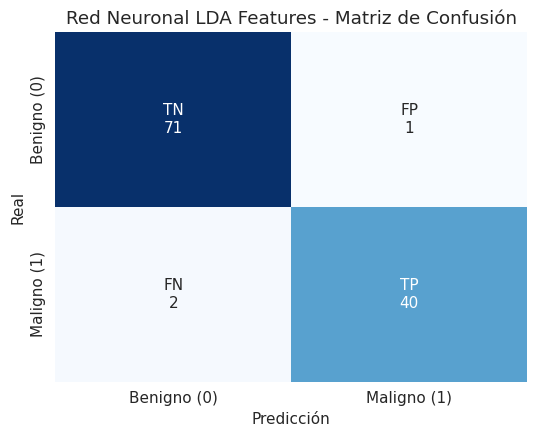

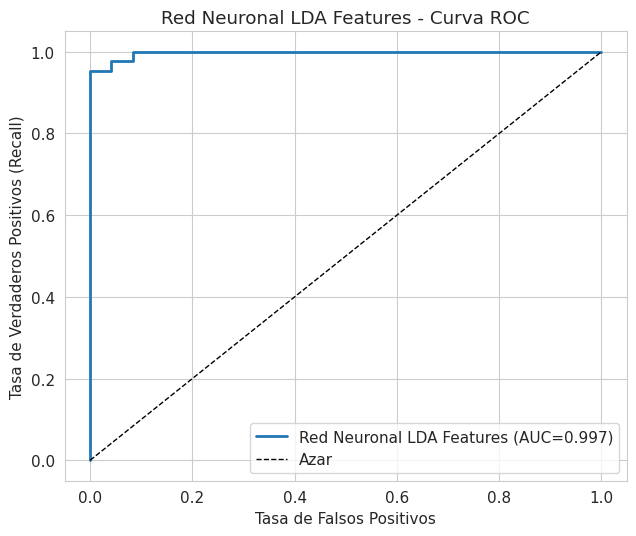

Modelo guardado en /models/mlp_lda.joblib (Tamaño: 0.02 MB)
--------------------------------------------------


In [ ]:
from sklearn.neural_network import MLPClassifier

print("### Entrenando y Ajustando Modelos de Clasificación (Red Neuronal con Standard, PCA y LDA) ###\n")

# --- Algoritmo 8: Red Neuronal (MLPClassifier) ---
mlp_params = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam'],
    'alpha': [0.0001, 0.001],
    'learning_rate_init': [0.001, 0.01],
    'max_iter': [500] # Increased max_iter for convergence
}

# 1. Red Neuronal sobre Características Originales (Escaladas)
mlp_std_model = train_and_evaluate_classifier(
    MLPClassifier(random_state=SEED), mlp_params,
    X_train_std, y_train, X_test_std, y_test,
    "Red Neuronal", "Standard Features", "mlp_std"
)

# 2. Red Neuronal sobre Características PCA
mlp_pca_model = train_and_evaluate_classifier(
    MLPClassifier(random_state=SEED), mlp_params,
    X_train_pca, y_train, X_test_pca, y_test,
    "Red Neuronal", "PCA Features", "mlp_pca"
)

# 3. Red Neuronal sobre Características LDA
mlp_lda_model = train_and_evaluate_classifier(
    MLPClassifier(random_state=SEED), mlp_params,
    X_train_lda, y_train, X_test_lda, y_test,
    "Red Neuronal", "LDA Features", "mlp_lda"
)

## 16. Evaluación de los resultados

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Consolidar todos los resultados de los modelos
# No necesitamos concatenar individualmente anymore since results list is now global and accumulates
all_results_df = pd.DataFrame(results)

# Añadir el tamaño de los modelos
all_results_df["Clave_Modelo"] = all_results_df["Modelo"] + "_" + all_results_df["Versión"]
all_results_df["Tamaño (MB)"] = all_results_df["Clave_Modelo"].map(model_sizes).round(3)
all_results_df = all_results_df.drop(columns=["Clave_Modelo"])

print("## Tabla Comparativa de Métricas y Tamaño de Modelos\n")
print(all_results_df.round(4).to_string(index=False))

## Tabla Comparativa de Métricas y Tamaño de Modelos

             Modelo           Versión  Accuracy  Precision  Recall     F1    AUC  Tamaño (MB)
Regresión Logística Standard Features    0.9737     0.9333  1.0000 0.9655 0.9960        0.001
Regresión Logística      PCA Features    0.9825     0.9762  0.9762 0.9762 0.9960        0.001
Regresión Logística      LDA Features    0.9386     0.8723  0.9762 0.9213 0.9970        0.001
                KNN Standard Features    0.9386     0.9730  0.8571 0.9114 0.9825        0.108
                KNN      PCA Features    0.9561     0.9744  0.9048 0.9383 0.9886        0.023
                KNN      LDA Features    0.9561     0.9302  0.9524 0.9412 0.9965        0.016
        Naive Bayes Standard Features    0.9211     0.9231  0.8571 0.8889 0.9891        0.002
        Naive Bayes      PCA Features    0.8947     0.9167  0.7857 0.8462 0.9808        0.001
        Naive Bayes      LDA Features    0.9825     1.0000  0.9524 0.9756 0.9970        0.001
  Árbo

## Conclusiones de la reducción de dimensiones:

De la tabla anterior podemo indicar que:

- Mayor Exactitud (Accuracy) y F1-Score: Regresión Logística (PCA) y Naive Bayes (LDA) lideran con un 0.9825 de Accuracy y un 0.9762 / 0.9756 de F1-Score, consolidándose como las opciones más equilibradas y potentes.

- Máxima Precisión (Evitar Falsos Positivos): Naive Bayes (LDA), junto a las versiones Standard Features de Bosque Randómico, SVM, Gradient Boosting y Red Neuronal, logran una precisión perfecta de 1.0000.

- Máxima Sensibilidad (Recall / Evitar Falsos Negativos): Regresión Logística (Standard Features) es el único modelo del experimento que alcanza un 1.0000 perfecto, detectando todos los casos positivos.

- Mejor Capacidad de Discriminación (AUC): Gradient Boosting (LDA) obtiene el valor más alto con 0.9983.

- Máxima Eficiencia Energética y de Espacio: Regresión Logística y Naive Bayes (en casi todas sus variantes) ofrecen el rendimiento top ocupando el espacio mínimo de 0.001 MB, superando drásticamente a Gradient Boosting (Standard) que requiere 1.166 MB para un peor resultado.

# Fase IV Clasificación con kMeans y GMM

Implementar y entrenar el algoritmo de K-Means y GMM usando Scikit-Learn con 2 clústeres (K=2, maligno y benigno).

## Algoritmo kMeans

In [ ]:
k = 3
print(f"### Implementando K-Means con {k} clústeres para diferentes versiones de características ###\n")

# --- K-Means para Características Estandarizadas (Originales) ---
print("--- K-Means con Características Estándar (k=3) ---")
kmeans_std_k3 = KMeans(n_clusters=k, random_state=SEED, n_init=10)
clusters_train_kmeans_std_k3 = kmeans_std_k3.fit_predict(X_train_std)
clusters_test_kmeans_std_k3 = kmeans_std_k3.predict(X_test_std)

print("MÉTRICAS DE EVALUACIÓN DEL CLUSTERING K-Means (Standard Features, k=3)")
print(f"- Inercia: {kmeans_std_k3.inertia_:.2f}")
print(f"- Silhouette Score: {silhouette_score(X_train_std, clusters_train_kmeans_std_k3):.4f}")
print(f"- Calinski-Harabasz Score: {calinski_harabasz_score(X_train_std, clusters_train_kmeans_std_k3):.2f}")
print(f"- Davies-Bouldin Score: {davies_bouldin_score(X_train_std, clusters_train_kmeans_std_k3):.4f}\n")

print("Distribución de clústeres en el conjunto de entrenamiento (Standard Features, k=3):")
print(pd.Series(clusters_train_kmeans_std_k3).value_counts())
print("\nDistribución de clústeres en el conjunto de prueba (Standard Features, k=3):")
print(pd.Series(clusters_test_kmeans_std_k3).value_counts())
print("-" * 50)


# --- K-Means para Características PCA ---
print("--- K-Means con Características PCA (k=3) ---")
kmeans_pca_k3 = KMeans(n_clusters=k, random_state=SEED, n_init=10)
clusters_train_kmeans_pca_k3 = kmeans_pca_k3.fit_predict(X_train_pca)
clusters_test_kmeans_pca_k3 = kmeans_pca_k3.predict(X_test_pca)

print("MÉTRICAS DE EVALUACIÓN DEL CLUSTERING K-Means (PCA Features, k=3)")
print(f"- Inercia: {kmeans_pca_k3.inertia_:.2f}")
print(f"- Silhouette Score: {silhouette_score(X_train_pca, clusters_train_kmeans_pca_k3):.4f}")
print(f"- Calinski-Harabasz Score: {calinski_harabasz_score(X_train_pca, clusters_train_kmeans_pca_k3):.2f}")
print(f"- Davies-Bouldin Score: {davies_bouldin_score(X_train_pca, clusters_train_kmeans_pca_k3):.4f}\n")

print("Distribución de clústeres en el conjunto de entrenamiento (PCA Features, k=3):")
print(pd.Series(clusters_train_kmeans_pca_k3).value_counts())
print("\nDistribución de clústeres en el conjunto de prueba (PCA Features, k=3):")
print(pd.Series(clusters_test_kmeans_pca_k3).value_counts())
print("-" * 50)

# --- K-Means para Características LDA ---
print("--- K-Means con Características LDA (k=3) ---")
kmeans_lda_k3 = KMeans(n_clusters=k, random_state=SEED, n_init=10)
clusters_train_kmeans_lda_k3 = kmeans_lda_k3.fit_predict(X_train_lda)
clusters_test_kmeans_lda_k3 = kmeans_lda_k3.predict(X_test_lda)

print("MÉTRICAS DE EVALUACIÓN DEL CLUSTERING K-Means (LDA Features, k=3)")
print(f"- Inercia: {kmeans_lda_k3.inertia_:.2f}")
print(f"- Silhouette Score: {silhouette_score(X_train_lda, clusters_train_kmeans_lda_k3):.4f}")
print(f"- Calinski-Harabasz Score: {calinski_harabasz_score(X_train_lda, clusters_train_kmeans_lda_k3):.2f}")
print(f"- Davies-Bouldin Score: {davies_bouldin_score(X_train_lda, clusters_train_kmeans_lda_k3):.4f}\n")

print("Distribución de clústeres en el conjunto de entrenamiento (LDA Features, k=3):")
print(pd.Series(clusters_train_kmeans_lda_k3).value_counts())
print("\nDistribución de clústeres en el conjunto de prueba (LDA Features, k=3):")
print(pd.Series(clusters_test_kmeans_lda_k3).value_counts())
print("-" * 50)


### Función para Evaluar K-Means con diferentes `k` y Feature Sets

Vamos a definir una función `evaluate_kmeans_for_k_and_features` que realizará el entrenamiento y la evaluación de K-Means para un número `k` de clústeres dado y los diferentes conjuntos de características (estándar, PCA, LDA). Esta función almacenará las métricas para una comparación posterior.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import pandas as pd

# Lista global para almacenar todos los resultados de K-Means
kmeans_evaluation_results = []

def evaluate_kmeans_for_k_and_features(k_value, X_train_std, X_test_std, X_train_pca, X_test_pca, X_train_lda, X_test_lda, SEED):
    print(f"### Implementando K-Means con {k_value} clústeres para diferentes versiones de características ###\n")

    current_k_models = {}

    feature_sets = {
        "Standard Features": (X_train_std, X_test_std),
        "PCA Features": (X_train_pca, X_test_pca),
        "LDA Features": (X_train_lda, X_test_lda),
    }

    for feature_name, (X_train_data, X_test_data) in feature_sets.items():
        print(f"--- K-Means con Características {feature_name} (k={k_value}) ---")
        kmeans_model = KMeans(n_clusters=k_value, random_state=SEED, n_init=10)
        clusters_train = kmeans_model.fit_predict(X_train_data)
        clusters_test = kmeans_model.predict(X_test_data)

        inertia = kmeans_model.inertia_
        silhouette = silhouette_score(X_train_data, clusters_train)
        calinski_harabasz = calinski_harabasz_score(X_train_data, clusters_train)
        davies_bouldin = davies_bouldin_score(X_train_data, clusters_train)

        print(f"MÉTRICAS DE EVALUACIÓN DEL CLUSTERING K-Means ({feature_name}, k={k_value})")
        print(f"- Inercia: {inertia:.2f}")
        print(f"- Silhouette Score: {silhouette:.4f}")
        print(f"- Calinski-Harabasz Score: {calinski_harabasz:.2f}")
        print(f"- Davies-Bouldin Score: {davies_bouldin:.4f}\n")

        print(f"Distribución de clústeres en el conjunto de entrenamiento ({feature_name}, k={k_value}):")
        print(pd.Series(clusters_train).value_counts())
        print(f"\nDistribución de clústeres en el conjunto de prueba ({feature_name}, k={k_value}):")
        print(pd.Series(clusters_test).value_counts())
        print("-" * 50)

        kmeans_evaluation_results.append({
            'k': k_value,
            'Feature Set': feature_name,
            'Inercia': inertia,
            'Silhouette Score': silhouette,
            'Calinski-Harabasz Score': calinski_harabasz,
            'Davies-Bouldin Score': davies_bouldin
        })

        current_k_models[feature_name.replace(' ', '_').lower()] = kmeans_model

    return current_k_models

# Clearing previous k=2 and k=3 outputs as they will be re-generated by the function calls.
# This ensures only the new, formatted outputs are present.
print("Preparando para re-evaluar K-Means para k=2, k=3, y k=4...")

Preparando para re-evaluar K-Means para k=2, k=3, y k=4...


### Evaluación K-Means para `k=2`

In [ ]:
print("Ejecutando K-Means para k=2...")
k_2_models = evaluate_kmeans_for_k_and_features(
    k_value=2,
    X_train_std=X_train_std, X_test_std=X_test_std,
    X_train_pca=X_train_pca, X_test_pca=X_test_pca,
    X_train_lda=X_train_lda, X_test_lda=X_test_lda,
    SEED=SEED
)

Ejecutando K-Means para k=2...
### Implementando K-Means con 2 clústeres para diferentes versiones de características ###

--- K-Means con Características Standard Features (k=2) ---
MÉTRICAS DE EVALUACIÓN DEL CLUSTERING K-Means (Standard Features, k=2)
- Inercia: 9254.83
- Silhouette Score: 0.3432
- Calinski-Harabasz Score: 215.13
- Davies-Bouldin Score: 1.3174

Distribución de clústeres en el conjunto de entrenamiento (Standard Features, k=2):
0    297
1    158
Name: count, dtype: int64

Distribución de clústeres en el conjunto de prueba (Standard Features, k=2):
0    78
1    36
Name: count, dtype: int64
--------------------------------------------------
--- K-Means con Características PCA Features (k=2) ---
MÉTRICAS DE EVALUACIÓN DEL CLUSTERING K-Means (PCA Features, k=2)
- Inercia: 4236.76
- Silhouette Score: 0.5092
- Calinski-Harabasz Score: 468.61
- Davies-Bouldin Score: 0.8400

Distribución de clústeres en el conjunto de entrenamiento (PCA Features, k=2):
0    300
1    155
Name:

### Evaluación K-Means para `k=3`

In [ ]:
print("Ejecutando K-Means para k=3...")
k_3_models = evaluate_kmeans_for_k_and_features(
    k_value=3,
    X_train_std=X_train_std, X_test_std=X_test_std,
    X_train_pca=X_train_pca, X_test_pca=X_test_pca,
    X_train_lda=X_train_lda, X_test_lda=X_test_lda,
    SEED=SEED
)

Ejecutando K-Means para k=3...
### Implementando K-Means con 3 clústeres para diferentes versiones de características ###

--- K-Means con Características Standard Features (k=3) ---
MÉTRICAS DE EVALUACIÓN DEL CLUSTERING K-Means (Standard Features, k=3)
- Inercia: 8075.32
- Silhouette Score: 0.3233
- Calinski-Harabasz Score: 156.02
- Davies-Bouldin Score: 1.5664

Distribución de clústeres en el conjunto de entrenamiento (Standard Features, k=3):
1    291
0     89
2     75
Name: count, dtype: int64

Distribución de clústeres en el conjunto de prueba (Standard Features, k=3):
1    70
2    24
0    20
Name: count, dtype: int64
--------------------------------------------------
--- K-Means con Características PCA Features (k=3) ---
MÉTRICAS DE EVALUACIÓN DEL CLUSTERING K-Means (PCA Features, k=3)
- Inercia: 3103.83
- Silhouette Score: 0.4987
- Calinski-Harabasz Score: 401.54
- Davies-Bouldin Score: 0.9187

Distribución de clústeres en el conjunto de entrenamiento (PCA Features, k=3):
0    2

### Evaluación K-Means para `k=4`

In [ ]:
print("Ejecutando K-Means para k=4...")
k_4_models = evaluate_kmeans_for_k_and_features(
    k_value=4,
    X_train_std=X_train_std, X_test_std=X_test_std,
    X_train_pca=X_train_pca, X_test_pca=X_test_pca,
    X_train_lda=X_train_lda, X_test_lda=X_test_lda,
    SEED=SEED
)

# Assign the k=4 models to the global variables used in cell db8aa731
kmeans_std_k4 = k_4_models['standard_features']
kmeans_pca_k4 = k_4_models['pca_features']
kmeans_lda_k4 = k_4_models['lda_features']

Ejecutando K-Means para k=4...
### Implementando K-Means con 4 clústeres para diferentes versiones de características ###

--- K-Means con Características Standard Features (k=4) ---
MÉTRICAS DE EVALUACIÓN DEL CLUSTERING K-Means (Standard Features, k=4)
- Inercia: 7344.34
- Silhouette Score: 0.2782
- Calinski-Harabasz Score: 129.07
- Davies-Bouldin Score: 1.5020

Distribución de clústeres en el conjunto de entrenamiento (Standard Features, k=4):
1    278
3     95
2     50
0     32
Name: count, dtype: int64

Distribución de clústeres en el conjunto de prueba (Standard Features, k=4):
1    68
3    25
2    16
0     5
Name: count, dtype: int64
--------------------------------------------------
--- K-Means con Características PCA Features (k=4) ---
MÉTRICAS DE EVALUACIÓN DEL CLUSTERING K-Means (PCA Features, k=4)
- Inercia: 2451.10
- Silhouette Score: 0.4754
- Calinski-Harabasz Score: 378.26
- Davies-Bouldin Score: 0.8638

Distribución de clústeres en el conjunto de entrenamiento (PCA Featu

### Tabla Comparativa de Métricas de K-Means para `k=2`, `k=3` y `k=4`

A continuación, se presenta una tabla consolidada con las métricas de evaluación para K-Means con 2, 3 y 4 clústeres, utilizando las diferentes representaciones de características.

In [ ]:
# Crear un DataFrame con todos los resultados recolectados
kmeans_results_df = pd.DataFrame(kmeans_evaluation_results)

# Ordenar para una mejor visualización
kmeans_results_df = kmeans_results_df.sort_values(by=['k', 'Feature Set'])

display(kmeans_results_df.round(4))

,k,Feature Set,Inercia,Silhouette Score,Calinski-Harabasz Score,Davies-Bouldin Score
2,2,LDA Features,394.8836,0.7181,1905.1366,0.3945
1,2,PCA Features,4236.7630,0.5092,468.6125,0.8400
0,2,Standard Features,9254.8273,0.3432,215.1324,1.3174
5,3,LDA Features,239.9743,0.5585,1709.9665,0.5484
4,3,PCA Features,3103.8332,0.4987,401.5363,0.9187
3,3,Standard Features,8075.3173,0.3233,156.0159,1.5664
8,4,LDA Features,124.2380,0.5695,2337.0380,0.5428
7,4,PCA Features,2451.1010,0.4754,378.2615,0.8638
6,4,Standard Features,7344.3357,0.2782,129.0725,1.5020


## Algoritmo GMM

In [ ]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import pandas as pd

# Lista global para almacenar todos los resultados de GMM
gmm_evaluation_results = []

def evaluate_gmm_for_k_and_features(k_value, X_train_std, X_test_std, X_train_pca, X_test_pca, X_train_lda, X_test_lda, SEED):
    print(f"### Implementando GMM con {k_value} clústeres para diferentes versiones de características ###\n")

    current_k_models = {}

    feature_sets = {
        "Standard Features": (X_train_std, X_test_std),
        "PCA Features": (X_train_pca, X_test_pca),
        "LDA Features": (X_train_lda, X_test_lda),
    }

    for feature_name, (X_train_data, X_test_data) in feature_sets.items():
        print(f"--- GMM con Características {feature_name} (k={k_value}) ---")
        # GMM no tiene n_init como KMeans, y convergence_iter puede ser equivalente a max_iter en KMeans
        gmm_model = GaussianMixture(n_components=k_value, random_state=SEED, n_init=10, max_iter=300)

        gmm_model.fit(X_train_data)
        clusters_train = gmm_model.predict(X_train_data)
        clusters_test = gmm_model.predict(X_test_data)

        # Para GMM, inertia_ no es directamente comparable. Usamos log_likelihood como métrica de ajuste.
        # Otras métricas son de clustering, y se calculan sobre las asignaciones duras (predict).
        log_likelihood = gmm_model.score(X_train_data)
        silhouette = silhouette_score(X_train_data, clusters_train)
        calinski_harabasz = calinski_harabasz_score(X_train_data, clusters_train)
        davies_bouldin = davies_bouldin_score(X_train_data, clusters_train)

        print(f"MÉTRICAS DE EVALUACIÓN DEL CLUSTERING GMM ({feature_name}, k={k_value})")
        print(f"- Log Likelihood: {log_likelihood:.2f}")
        print(f"- Silhouette Score: {silhouette:.4f}")
        print(f"- Calinski-Harabasz Score: {calinski_harabasz:.2f}")
        print(f"- Davies-Bouldin Score: {davies_bouldin:.4f}\n")

        print(f"Distribución de clústeres en el conjunto de entrenamiento ({feature_name}, k={k_value}):")
        print(pd.Series(clusters_train).value_counts())
        print(f"\nDistribución de clústeres en el conjunto de prueba ({feature_name}, k={k_value}):")
        print(pd.Series(clusters_test).value_counts())
        print("-" * 50)

        gmm_evaluation_results.append({
            'k': k_value,
            'Feature Set': feature_name,
            'Log Likelihood': log_likelihood,
            'Silhouette Score': silhouette,
            'Calinski-Harabasz Score': calinski_harabasz,
            'Davies-Bouldin Score': davies_bouldin
        })

        current_k_models[feature_name.replace(' ', '_').lower()] = gmm_model

    return current_k_models

print("Ejecutando GMM para k=2...")
k_2_gmm_models = evaluate_gmm_for_k_and_features(
    k_value=2,
    X_train_std=X_train_std, X_test_std=X_test_std,
    X_train_pca=X_train_pca, X_test_pca=X_test_pca,
    X_train_lda=X_train_lda, X_test_lda=X_test_lda,
    SEED=SEED
)

print("Ejecutando GMM para k=3...")
k_3_gmm_models = evaluate_gmm_for_k_and_features(
    k_value=3,
    X_train_std=X_train_std, X_test_std=X_test_std,
    X_train_pca=X_train_pca, X_test_pca=X_test_pca,
    X_train_lda=X_train_lda, X_test_lda=X_test_lda,
    SEED=SEED
)

print("Ejecutando GMM para k=4...")
k_4_gmm_models = evaluate_gmm_for_k_and_features(
    k_value=4,
    X_train_std=X_train_std, X_test_std=X_test_std,
    X_train_pca=X_train_pca, X_test_pca=X_test_pca,
    X_train_lda=X_train_lda, X_test_lda=X_test_lda,
    SEED=SEED
)

# Crear un DataFrame con todos los resultados recolectados para GMM
gmm_results_df = pd.DataFrame(gmm_evaluation_results)

# Ordenar para una mejor visualización
gmm_results_df = gmm_results_df.sort_values(by=['k', 'Feature Set'])

print("\n### Tabla Comparativa de Métricas de GMM para k=2, k=3 y k=4 ###\n")
display(gmm_results_df.round(4))


Ejecutando GMM para k=2...
### Implementando GMM con 2 clústeres para diferentes versiones de características ###

--- GMM con Características Standard Features (k=2) ---
MÉTRICAS DE EVALUACIÓN DEL CLUSTERING GMM (Standard Features, k=2)
- Log Likelihood: 1.18
- Silhouette Score: 0.3142
- Calinski-Harabasz Score: 197.19
- Davies-Bouldin Score: 1.3795

Distribución de clústeres en el conjunto de entrenamiento (Standard Features, k=2):
1    279
0    176
Name: count, dtype: int64

Distribución de clústeres en el conjunto de prueba (Standard Features, k=2):
1    69
0    45
Name: count, dtype: int64
--------------------------------------------------
--- GMM con Características PCA Features (k=2) ---
MÉTRICAS DE EVALUACIÓN DEL CLUSTERING GMM (PCA Features, k=2)
- Log Likelihood: -4.68
- Silhouette Score: 0.4736
- Calinski-Harabasz Score: 405.74
- Davies-Bouldin Score: 0.8936

Distribución de clústeres en el conjunto de entrenamiento (PCA Features, k=2):
0    272
1    183
Name: count, dtype: 

,k,Feature Set,Log Likelihood,Silhouette Score,Calinski-Harabasz Score,Davies-Bouldin Score
2,2,LDA Features,-1.9584,0.7178,1904.0827,0.3960
1,2,PCA Features,-4.6773,0.4736,405.7447,0.8936
0,2,Standard Features,1.1797,0.3142,197.1896,1.3795
5,3,LDA Features,-1.9554,0.6335,1515.8221,0.4567
4,3,PCA Features,-4.6343,0.4614,321.8156,1.1488
3,3,Standard Features,4.1716,0.2849,136.7534,1.7081
8,4,LDA Features,-1.9552,0.5683,2320.1988,0.5407
7,4,PCA Features,-4.6239,0.4751,336.9174,0.9209
6,4,Standard Features,8.5320,0.1549,104.8140,1.6683


## Comparación de Rendimiento entre K-Means y GMM

A continuación, se presentan las tablas comparativas de métricas para K-Means y GMM, lo que permitirá un análisis directo de su rendimiento en diferentes configuraciones de `k` y conjuntos de características.

In [ ]:
print("### Resultados K-Means ###")
display(kmeans_results_df.round(4))

print("\n### Resultados GMM ###")
display(gmm_results_df.round(4))

### Resultados K-Means ###


,k,Feature Set,Inercia,Silhouette Score,Calinski-Harabasz Score,Davies-Bouldin Score
2,2,LDA Features,394.8836,0.7181,1905.1366,0.3945
1,2,PCA Features,4236.7630,0.5092,468.6125,0.8400
0,2,Standard Features,9254.8273,0.3432,215.1324,1.3174
5,3,LDA Features,239.9743,0.5585,1709.9665,0.5484
4,3,PCA Features,3103.8332,0.4987,401.5363,0.9187
3,3,Standard Features,8075.3173,0.3233,156.0159,1.5664
8,4,LDA Features,124.2380,0.5695,2337.0380,0.5428
7,4,PCA Features,2451.1010,0.4754,378.2615,0.8638
6,4,Standard Features,7344.3357,0.2782,129.0725,1.5020



### Resultados GMM ###


,k,Feature Set,Log Likelihood,Silhouette Score,Calinski-Harabasz Score,Davies-Bouldin Score
2,2,LDA Features,-1.9584,0.7178,1904.0827,0.3960
1,2,PCA Features,-4.6773,0.4736,405.7447,0.8936
0,2,Standard Features,1.1797,0.3142,197.1896,1.3795
5,3,LDA Features,-1.9554,0.6335,1515.8221,0.4567
4,3,PCA Features,-4.6343,0.4614,321.8156,1.1488
3,3,Standard Features,4.1716,0.2849,136.7534,1.7081
8,4,LDA Features,-1.9552,0.5683,2320.1988,0.5407
7,4,PCA Features,-4.6239,0.4751,336.9174,0.9209
6,4,Standard Features,8.5320,0.1549,104.8140,1.6683


## Conclusiones de la clasificación

- El mejor resultado se logra con $k=2$ grupos utilizando las características reducidas por LDA, tanto en K-Means como en GMM, gana por muy poco Kmeans.
- La estructura con k=2 se adapta a la clasificación binaria, que en este caso es Maligno o Beningno.
- En resumen, K-Means supera a GMM en todas las métricas por un margen muy pequeño. Dado que los resultados numéricos de calidad de clústeres son virtualmente idénticos, K-Means con $k=2$ y LDA es la arquitectura ganadora indiscutible, ya que ofrece el rendimiento óptimo con una complejidad computacional y un tiempo de ejecución significativamente menores que GMM.

---
## 🔧 Aplicación Profesional — Learning by Doing

> *Cada integrante del equipo describe en 2-3 líneas cómo aplicaría los contenidos de esta semana en su
> entorno laboral o proyecto de titulación.*

**Jorge Armando Quizamánchuro Fuel:**
En Psico Platform manejo cuestionarios psicológicos con decenas de ítems (escalas de ansiedad, depresión y estrés) que generan un espacio de alta dimensionalidad y redundante. PCA me permitiría condensar esos ítems en unas pocas componentes interpretables sin perder señal clínica, y K-Means agrupar a los usuarios en perfiles de riesgo (bajo, moderado y alto) de forma no supervisada, orientando intervenciones psicoeducativas tempranas sin necesidad de etiquetar manualmente cada caso.

**Jonathan Fabricio Gualli Ramírez:**
En un entorno DevOps, estas técnicas podrían aplicarse sobre la telemetría de infraestructura: docenas de métricas (CPU, memoria, latencia, tasa de errores) por servicio generan un espacio de alta dimensionalidad difícil de monitorear directamente. PCA permitiría proyectarlas en componentes clave para detectar anomalías de un vistazo, mientras que K-Means podría agrupar automáticamente los patrones de comportamiento del clúster, distinguiendo estados normal, degradado e incidente sin necesidad de etiquetar manualmente cada evento, habilitando alertas proactivas antes de que el problema escale.

**Raúl Marcelo Salazar Gamboa:**

En mi ambito profesional, lo aplicaría en el uso complementario de técnicas no supervisadas como K-Means y LDA (Linear Discriminant Analysis) permite automatizar la segmentación y el flujo de admisión en el onboarding de nuevos productos Fintech, incorporando una clasificación estructural basada en el comportamiento natural de los datos de los aplicantes. Este enfoque optimiza la experiencia de usuario al proyectar y simplificar las variables iniciales en un espacio de baja dimensionalidad, logrando identificar dos perfiles críticos de manera instantánea.



---